# Initial Packages and dependencies

In [ ]:
!pip install pyarabic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 4.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Helper Functions

## Remove punctuation

In [ ]:
import re

def remove_punct(text):
    return re.sub(r"[^\w\s]", "", str(text), flags=re.UNICODE)

## Remove tashkeel

In [ ]:
import re
import pyarabic.araby as araby

def clean_noise(text):
    text = araby.strip_tashkeel(text) # Removes Fatha, Damma, etc.
    text = araby.strip_tatweel(text)  # Removes elongation (_)
    text = re.sub(r'(.)\1{2,}', r'\1', text)     # تقليل تكرار الحروف (3 مرات أو أكثر → مرة وحدة)
    return text


## Normalize

In [ ]:
import unicodedata
def normalize_arabic(text):
    text = unicodedata.normalize('NFKC', text)
    text = araby.normalize_alef(text)      # أ إ آ -> ا
    text = araby.normalize_hamza(text)     # ؤ ئ -> ء (depending on strategy)
    text = araby.normalize_teh(text)       # ة -> ه
    text = araby.normalize_ligature(text)  # ﻻ -> ل ا
    return text

#1 DOHA DATASET

In [ ]:
dohaDB = pd.read_csv("/content/MADAR.corpus.Doha - MADAR.corpus.Doha.csv")
dohaDB.head()

,sentID.BTEC,split,lang,sent_DOH
0,0,corpus-6-train,DOH,موجود في نهاية الممر، بجيب لك شوي الحين. اذا ا...
1,2,corpus-6-train,DOH,تسوي تعديلات؟
2,4,corpus-6-train,DOH,بغينا طاولة يم الدريشة.
3,5,corpus-6-test-corpus-26-train,DOH,هو ذاك الصوب، بالضبط جدام استعلامات السياح بال...
4,9,corpus-6-test-corpus-26-train,DOH,ما قط سمعت بهالعنوان في هالمنطقة من قبل.


In [ ]:
dohaDB.sample(3)

,sentID.BTEC,split,lang,sent_DOH
6639,11142,corpus-6-train,DOH,عندك جولة للاس فيغاس؟
654,1059,corpus-6-train,DOH,عطني علوج، لو سمحت.
9150,15246,corpus-6-test-corpus-26-train,DOH,عربة عادية ولا عربة نوم؟


dataset length is 12k index which are numbers of the rows
all the sent_DOH data type is object

In [ ]:
dohaDB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sentID.BTEC  12000 non-null  int64 
 1   split        12000 non-null  object
 2   lang         12000 non-null  object
 3   sent_DOH     12000 non-null  object
dtypes: int64(1), object(3)
memory usage: 375.1+ KB


In [ ]:
len(dohaDB)

12000

null data == 0

In [ ]:
dohaDB.isnull().sum()

,0
sentID.BTEC,0
split,0
lang,0
sent_DOH,0


In [ ]:
dohaDB.duplicated().sum()

np.int64(0)

In [ ]:
dohaDB.duplicated(subset=['sent_DOH'], keep="first").sum()

np.int64(259)

##Remove punctuation

In [ ]:
dohaDB["sent_DOH_punctuation_removed"] = dohaDB["sent_DOH"].astype(str).apply(remove_punct)
dohaDB


,sentID.BTEC,split,lang,sent_DOH,sent_DOH_punctuation_removed
0,0,corpus-6-train,DOH,موجود في نهاية الممر، بجيب لك شوي الحين. اذا ا...,موجود في نهاية الممر بجيب لك شوي الحين اذا احت...
1,2,corpus-6-train,DOH,تسوي تعديلات؟,تسوي تعديلات
2,4,corpus-6-train,DOH,بغينا طاولة يم الدريشة.,بغينا طاولة يم الدريشة
3,5,corpus-6-test-corpus-26-train,DOH,هو ذاك الصوب، بالضبط جدام استعلامات السياح بال...,هو ذاك الصوب بالضبط جدام استعلامات السياح بالضبط
4,9,corpus-6-test-corpus-26-train,DOH,ما قط سمعت بهالعنوان في هالمنطقة من قبل.,ما قط سمعت بهالعنوان في هالمنطقة من قبل
...,...,...,...,...,...
11995,19959,corpus-6-test-corpus-26-train,DOH,في حمام في المحطة.,في حمام في المحطة
11996,19960,corpus-6-train,DOH,خله طويل.,خله طويل
11997,19965,corpus-6-train,DOH,خلص البترول.,خلص البترول
11998,19968,corpus-6-train,DOH,ممكن تعطيني اي كرسيين متوفرين حق الليلة؟,ممكن تعطيني اي كرسيين متوفرين حق الليلة


##Remove tashkeel

In [ ]:
dohaDB["sent_DOH_punctuation_removed_and_tashkeel"] = dohaDB["sent_DOH_punctuation_removed"].astype(str).apply(clean_noise)
dohaDB.sample(3)

,sentID.BTEC,split,lang,sent_DOH,sent_DOH_punctuation_removed,sent_DOH_punctuation_removed_and_tashkeel
11362,18920,corpus-6-train,DOH,باخذ هذي وهذي وهذي، لو سمحت.,باخذ هذي وهذي وهذي لو سمحت,باخذ هذي وهذي وهذي لو سمحت
5948,9960,corpus-6-dev,DOH,ممكن تسوي ريوقي ساعة قبل هذي؟,ممكن تسوي ريوقي ساعة قبل هذي,ممكن تسوي ريوقي ساعة قبل هذي
11375,18938,corpus-6-test-corpus-26-train,DOH,قهوة مع سكر.,قهوة مع سكر,قهوة مع سكر


##Normalization

In [ ]:
dohaDB["sent_DOH_punctuation_removed_and_tashkeel_and_normlaized"] = dohaDB["sent_DOH_punctuation_removed_and_tashkeel"].astype(str).apply(normalize_arabic)
dohaDB.sample(3)
dohaDB.iloc[6911]

,6911
sentID.BTEC,11575
split,corpus-6-train
lang,DOH
sent_DOH,آخر ظهري يألمني.
sent_DOH_punctuation_removed,آخر ظهري يألمني
sent_DOH_punctuation_removed_and_tashkeel,آخر ظهري يألمني
sent_DOH_punctuation_removed_and_tashkeel_and_normlaized,اخر ظهري يالمني


## Exact Deduplication


In [ ]:
#help(dohaDB.drop_duplicates)

In [ ]:
dohaDB.duplicated(subset=['sent_DOH_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum()

np.int64(282)

duplicate rows increased after cleansing it was 259

Here we can notice that there are duplicate rows that have similar values.

In [ ]:
dohaDB.query("sent_DOH_punctuation_removed_and_tashkeel_and_normlaized =='بغينا طاوله يم الدريشه'")

,sentID.BTEC,split,lang,sent_DOH,sent_DOH_punctuation_removed,sent_DOH_punctuation_removed_and_tashkeel,sent_DOH_punctuation_removed_and_tashkeel_and_normlaized
2,4,corpus-6-train,DOH,بغينا طاولة يم الدريشة.,بغينا طاولة يم الدريشة,بغينا طاولة يم الدريشة,بغينا طاوله يم الدريشه
3266,5504,corpus-6-train,DOH,بغينا طاولة يم الدريشة.,بغينا طاولة يم الدريشة,بغينا طاولة يم الدريشة,بغينا طاوله يم الدريشه


In [ ]:
dups_all_doha = dohaDB[dohaDB.duplicated(subset=['sent_DOH_punctuation_removed_and_tashkeel_and_normlaized'], keep="first")].copy()
dups_all_doha.head(2)

,sentID.BTEC,split,lang,sent_DOH,sent_DOH_punctuation_removed,sent_DOH_punctuation_removed_and_tashkeel,sent_DOH_punctuation_removed_and_tashkeel_and_normlaized
698,1132,corpus-6-train,DOH,بغيت دلاغات.,بغيت دلاغات,بغيت دلاغات,بغيت دلاغات
1248,2075,corpus-6-train,DOH,بغيت حليب، لو سمحت.,بغيت حليب لو سمحت,بغيت حليب لو سمحت,بغيت حليب لو سمحت


Deduplication 12000-11718=282

In [ ]:
print(len(dohaDB))
dohaDB_Deduplication = dohaDB.drop_duplicates(subset=["sent_DOH_punctuation_removed_and_tashkeel_and_normlaized"], keep="first").copy()
print(len(dohaDB_Deduplication))

12000
11718


all the duplicates were removed, np.int64(0) == 0

In [ ]:
dohaDB_Deduplication.duplicated(subset=['sent_DOH_punctuation_removed_and_tashkeel_and_normlaized']).sum()

np.int64(0)

In [ ]:
dups_all_doha.to_csv('Doha_dups_all.csv') #data that dublicated

In [ ]:
dohaDB_Deduplication.to_csv('dohaDB_Deduplication.csv') #data if we keep the first and remove the second duplicated rows

In [ ]:
print(len(dohaDB_Deduplication))
print(len(dups_all_doha))

11718
282


In [ ]:
print(len(dohaDB)) #data only cleaned
print(len(dohaDB_Deduplication)) # data without duplicated values
print(len(dups_all_doha))#all the duplicated values

12000
11718
282


Punctuation was removed and the text was normalized.
The dataset is mostly without tashkeel,but we still removed tashkeel if it appears in any rows to keep the text consistent.

NOW Im ganna do the same for the rest

#2 Cairo DATASET

In [ ]:
cairoDB = pd.read_csv("/content/MADAR.corpus.Cairo - MADAR.corpus.Cairo.csv")
cairoDB.head()

,sentID.BTEC,split,lang,sent_CAI
0,0,corpus-6-train,CAI,هو في اخر القاعة . أنا حأجيبلك شويه دلوقتي . ل...
1,2,corpus-6-train,CAI,بتعمل تبديلات؟
2,4,corpus-6-train,CAI,عايزين ترابيزة جنب الشباك .
3,5,corpus-6-test-corpus-26-train,CAI,ده قدامك هناك، يادوبك قدام مكتب استعلامات السي...
4,9,corpus-6-test-corpus-26-train,CAI,عمري ما سمعت عن العنوان ده هنا .


In [ ]:
cairoDB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sentID.BTEC  12000 non-null  int64 
 1   split        12000 non-null  object
 2   lang         12000 non-null  object
 3   sent_CAI     12000 non-null  object
dtypes: int64(1), object(3)
memory usage: 375.1+ KB


In [ ]:
cairoDB.notnull().sum()

,0
sentID.BTEC,12000
split,12000
lang,12000
sent_CAI,12000


In [ ]:
cairoDB.isnull().sum() # there aren't any null values

,0
sentID.BTEC,0
split,0
lang,0
sent_CAI,0


In [ ]:
cairoDB.sample() # need cleansing

,sentID.BTEC,split,lang,sent_CAI
10653,17762,corpus-6-train,CAI,هو أنا محتاج أدفع مقدم؟


In [ ]:
cairoDB.duplicated().sum() # no duplicated rows! This function checks if there are any duplicates on the id, label, not the sentences

np.int64(0)

In [ ]:
cairoDB.duplicated(subset=['sent_CAI'], keep="first").sum() # we can see there are only 88 duplicate row, but it might increase after cleansing
# This function checks if there are any repeated values with different indexes.

np.int64(88)

In [ ]:
len(cairoDB)

12000

##Remove puctuation

In [ ]:
cairoDB["sent_CAI_punctuation_removed"] = cairoDB["sent_CAI"].astype(str).apply(remove_punct)
cairoDB.sample(3)


,sentID.BTEC,split,lang,sent_CAI,sent_CAI_punctuation_removed
6820,11439,corpus-6-train,CAI,امتى نهائيات دوري كرة السله الامريكي للمحترفين؟,امتى نهائيات دوري كرة السله الامريكي للمحترفين
7984,13308,corpus-6-train,CAI,أعتقد إننا ممكن نحضر لك تربيزة خلال خمستاشر دق...,أعتقد إننا ممكن نحضر لك تربيزة خلال خمستاشر دقيقة
7205,12060,corpus-6-test-corpus-26-dev,CAI,فرخة مشوية، من فضلك.,فرخة مشوية من فضلك


##Remove tashkeel

In [ ]:
cairoDB["sent_CAI_punctuation_removed_and_tashkeel"] = cairoDB["sent_CAI_punctuation_removed"].astype(str).apply(clean_noise)
cairoDB.sample(3)

,sentID.BTEC,split,lang,sent_CAI,sent_CAI_punctuation_removed,sent_CAI_punctuation_removed_and_tashkeel
565,909,corpus-6-train,CAI,لو سمحت عايز حاجة انشف بيها .,لو سمحت عايز حاجة انشف بيها,لو سمحت عايز حاجة انشف بيها
5485,9224,corpus-6-train,CAI,انا عارف اللي انتي حاسة بالظبط .,انا عارف اللي انتي حاسة بالظبط,انا عارف اللي انتي حاسة بالظبط
9466,15766,corpus-6-train,CAI,هاسأل لو ينفع آخد صورة معاه.,هاسأل لو ينفع آخد صورة معاه,هاسأل لو ينفع آخد صورة معاه


##Normalization

In [ ]:
cairoDB["sent_CAI_punctuation_removed_and_tashkeel_and_normlaized"] = cairoDB["sent_CAI_punctuation_removed_and_tashkeel"].astype(str).apply(normalize_arabic)
cairoDB.sample(3)
#cairoDB.iloc[6399]

,sentID.BTEC,split,lang,sent_CAI,sent_CAI_punctuation_removed,sent_CAI_punctuation_removed_and_tashkeel,sent_CAI_punctuation_removed_and_tashkeel_and_normlaized
1110,1823,corpus-6-train,CAI,محتاجه ضروري .,محتاجه ضروري,محتاجه ضروري,محتاجه ضروري
3196,5387,corpus-6-train,CAI,مش عارف .,مش عارف,مش عارف,مش عارف
4405,7402,corpus-6-train,CAI,عاوز لبن سخن، من فضلك .,عاوز لبن سخن من فضلك,عاوز لبن سخن من فضلك,عاوز لبن سخن من فضلك


##Exact Deduplication

Duplicate rows increased from 88 to 107 after text cleaning (punctuation/tashkeel removal and normalization).

In [ ]:
cairoDB.duplicated(subset=['sent_CAI_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum()

np.int64(107)

In [ ]:
cairoDB.duplicated(subset=['sent_CAI'], keep="first").sum()

np.int64(88)

In [ ]:
print(len(cairoDB))
cairoDB_Deduplication = cairoDB.drop_duplicates(subset=["sent_CAI_punctuation_removed_and_tashkeel_and_normlaized"], keep="first").copy()
print(len(cairoDB_Deduplication))

12000
11893


In [ ]:
print(cairoDB_Deduplication.duplicated(subset=['sent_CAI_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum())
print(cairoDB.duplicated(subset=['sent_CAI_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum())

0
107


In [ ]:
dups_all_Cairo = cairoDB[cairoDB.duplicated(subset=['sent_CAI_punctuation_removed_and_tashkeel_and_normlaized'], keep="first")].copy()
dups_all_Cairo.head(2)

,sentID.BTEC,split,lang,sent_CAI,sent_CAI_punctuation_removed,sent_CAI_punctuation_removed_and_tashkeel,sent_CAI_punctuation_removed_and_tashkeel_and_normlaized
536,863,corpus-6-train,CAI,تمام . عندك اى اعراض جانبية او حساسية.,تمام عندك اى اعراض جانبية او حساسية,تمام عندك اى اعراض جانبية او حساسية,تمام عندك اا اعراض جانبيه او حساسيه
698,1132,corpus-6-train,CAI,عايز شوية شرابات .,عايز شوية شرابات,عايز شوية شرابات,عايز شويه شرابات


In [ ]:
print(len(cairoDB)) #data only cleaned
print(len(cairoDB_Deduplication))# data without duplicated values
print(len(dups_all_Cairo))#all the duplicated values

12000
11893
107


In [ ]:
dups_all_Cairo.to_csv('cairo_dups_all.csv') #data that dublicated

In [ ]:
cairoDB_Deduplication.to_csv('cairoDB_Deduplication.csv') #data if we keep the first and remove the second duplicated rows

# 3 Beirut DATASET

In [ ]:
beirutDB = pd.read_csv("/content/MADAR.corpus.Beirut - MADAR.corpus.Beirut.csv")
beirutDB.sample(3)

,sentID.BTEC,split,lang,sent_BEI
11277,18773,corpus-6-train,BEI,بتمنى تجي مرة تانية.
6918,11584,corpus-6-train,BEI,شنطي مش هون .
7918,13203,corpus-6-train,BEI,بشوفك، اتصل بقدر الليلة.


In [ ]:
beirutDB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sentID.BTEC  12000 non-null  int64 
 1   split        12000 non-null  object
 2   lang         12000 non-null  object
 3   sent_BEI     12000 non-null  object
dtypes: int64(1), object(3)
memory usage: 375.1+ KB


In [ ]:
beirutDB.isnull().sum() # null values==0

,0
sentID.BTEC,0
split,0
lang,0
sent_BEI,0


In [ ]:
beirutDB.duplicated().sum()

np.int64(0)

In [ ]:
beirutDB.duplicated(subset=["sent_BEI"],keep="first").sum() # Here we got 106 values are repeated, lets see after cleansing

np.int64(106)

##Remove puctuation

In [ ]:
beirutDB["sent_BEI_punctuation_removed"] = beirutDB["sent_BEI"].astype(str).apply(remove_punct)
beirutDB.sample(3)


,sentID.BTEC,split,lang,sent_BEI,sent_BEI_punctuation_removed
2322,3907,corpus-6-dev,BEI,مانشستر إذا بتريد .,مانشستر إذا بتريد
6827,11448,corpus-6-train,BEI,رح نتابع التطوارات منيح بعد ما نرجع عاليابان .,رح نتابع التطوارات منيح بعد ما نرجع عاليابان
7996,13323,corpus-6-train,BEI,أي نوع ويسكي عندك؟,أي نوع ويسكي عندك


##Remove tashkeel

In [ ]:
beirutDB["sent_BEI_punctuation_removed_and_tashkeel"] = beirutDB["sent_BEI_punctuation_removed"].astype(str).apply(clean_noise)
beirutDB.sample(3)

,sentID.BTEC,split,lang,sent_BEI,sent_BEI_punctuation_removed,sent_BEI_punctuation_removed_and_tashkeel
2527,4235,corpus-6-train,BEI,بعتو عن طريق البريد المسجل .,بعتو عن طريق البريد المسجل,بعتو عن طريق البريد المسجل
3998,6699,corpus-6-test-corpus-26-train,BEI,ما بدي واحد ضخم .,ما بدي واحد ضخم,ما بدي واحد ضخم
326,547,corpus-6-train,BEI,بدي شوية لحم غنم.,بدي شوية لحم غنم,بدي شوية لحم غنم


##Normalization

In [ ]:
beirutDB["sent_BEI_punctuation_removed_and_tashkeel_and_normlaized"] = beirutDB["sent_BEI_punctuation_removed_and_tashkeel"].astype(str).apply(normalize_arabic)
beirutDB.sample(3)
#beirutDB.iloc[1588]

,sentID.BTEC,split,lang,sent_BEI,sent_BEI_punctuation_removed,sent_BEI_punctuation_removed_and_tashkeel,sent_BEI_punctuation_removed_and_tashkeel_and_normlaized
5147,8663,corpus-6-train,BEI,عنجد ما بعرف . فيك تقيسني إذا بتريد؟,عنجد ما بعرف فيك تقيسني إذا بتريد,عنجد ما بعرف فيك تقيسني إذا بتريد,عنجد ما بعرف فيك تقيسني اذا بتريد
4103,6884,corpus-6-train,BEI,الاخضر .,الاخضر,الاخضر,الاخضر
11872,19755,corpus-6-test-corpus-26-train,BEI,بروح عالسكي مرتين بالشهر بالموسم.,بروح عالسكي مرتين بالشهر بالموسم,بروح عالسكي مرتين بالشهر بالموسم,بروح عالسكي مرتين بالشهر بالموسم


##Exact Deduplication

Duplicate rows increased from 106 to 121 after text cleaning (punctuation/tashkeel removal and normalization).

In [ ]:
beirutDB.duplicated(subset=['sent_BEI_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum()

np.int64(121)

In [ ]:
beirutDB.duplicated(subset=['sent_BEI'], keep="first").sum()

np.int64(106)

In [ ]:
print(len(beirutDB))
beirutDB_Deduplication = beirutDB.drop_duplicates(subset=["sent_BEI_punctuation_removed_and_tashkeel_and_normlaized"], keep="first").copy()
print(len(beirutDB_Deduplication))

12000
11879


In [ ]:
print(beirutDB_Deduplication.duplicated(subset=['sent_BEI_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum())
print(beirutDB.duplicated(subset=['sent_BEI_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum())

0
121


In [ ]:
dups_all_beirut = beirutDB[beirutDB.duplicated(subset=['sent_BEI_punctuation_removed_and_tashkeel_and_normlaized'], keep="first")].copy()
dups_all_beirut.head(2)

,sentID.BTEC,split,lang,sent_BEI,sent_BEI_punctuation_removed,sent_BEI_punctuation_removed_and_tashkeel,sent_BEI_punctuation_removed_and_tashkeel_and_normlaized
729,1179,corpus-6-train,BEI,لاء، يسلمو .,لاء يسلمو,لاء يسلمو,لاء يسلمو
1160,1916,corpus-6-train,BEI,عمول معروف خلي هالشنطات للساعة تلاتة .,عمول معروف خلي هالشنطات للساعة تلاتة,عمول معروف خلي هالشنطات للساعة تلاتة,عمول معروف خلي هالشنطات للساعه تلاته


In [ ]:
dups_all_beirut.to_csv('beirut_dups_all.csv') #data that dublicated

In [ ]:
beirutDB_Deduplication.to_csv('beirutDB_Deduplication.csv') #data if we keep the first and remove the second duplicated rows

# 4 Kuwait DATASET

In [ ]:
KuwaitDB = pd.read_csv("/content/MADAR.corpus.KW - MADAR.corpus.KW.csv")
KuwaitDB.sample(3)

,sentID.BTEC,split,lang,sent,sent_kuwaiti
1767,2965,corpus-6-dev,MSA,هذه القهوة أثقل من اللازم .,هالقهوة ثقيلة حيل.
187,312,corpus-6-train,MSA,من فضلك أعطني بعض الشاش .,لو سمحت عطني شوية شاش.
2281,3847,corpus-6-test-corpus-26-train,MSA,أنا خارج الآن . لذلك سآخذها .,أنا طالع الحين. عشان جذي باخذها.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
KuwaitDB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sentID.BTEC   12000 non-null  int64 
 1   split         12000 non-null  object
 2   lang          12000 non-null  object
 3   sent          12000 non-null  object
 4   sent_kuwaiti  12000 non-null  object
dtypes: int64(1), object(4)
memory usage: 468.9+ KB


In [ ]:
KuwaitDB.isnull().sum() # null values==0

,0
sentID.BTEC,0
split,0
lang,0
sent,0
sent_kuwaiti,0


In [ ]:
KuwaitDB.duplicated().sum()

np.int64(0)

In [ ]:
KuwaitDB.duplicated(subset=["sent_kuwaiti"],keep="first").sum() # Here we got 106 values are repeated, lets see after cleansing

np.int64(135)

##Remove puctuation

In [ ]:
KuwaitDB["sent_kuwaiti_punctuation_removed"] = KuwaitDB["sent_kuwaiti"].astype(str).apply(remove_punct)
KuwaitDB["sent_punctuation_removed"] = KuwaitDB["sent"].astype(str).apply(remove_punct)

KuwaitDB.sample(3)


,sentID.BTEC,split,lang,sent,sent_kuwaiti,sent_kuwaiti_punctuation_removed,sent_punctuation_removed
5070,8531,corpus-6-train,MSA,احضر إلى هنا في غضون ساعة من فضلك .,تعال هني خلال ساعة لو سمحت.,تعال هني خلال ساعة لو سمحت,احضر إلى هنا في غضون ساعة من فضلك
9948,16587,corpus-6-train,MSA,أين أفضل مكان يمكنني زيارته مع صديقي ؟,وين أحسن مكان أقدر أزوره مع صديقي؟,وين أحسن مكان أقدر أزوره مع صديقي,أين أفضل مكان يمكنني زيارته مع صديقي
7732,12915,corpus-6-train,MSA,أرجو أن تحتفظ بهذه الحقائب لمدة أسبوع .,ممكن تحتفظ بهالجنط لمدة أسبوع؟,ممكن تحتفظ بهالجنط لمدة أسبوع,أرجو أن تحتفظ بهذه الحقائب لمدة أسبوع


##Remove tashkeel

In [ ]:
KuwaitDB["sent_kuwaiti_punctuation_removed_and_tashkeel"] = KuwaitDB["sent_kuwaiti_punctuation_removed"].astype(str).apply(clean_noise)
KuwaitDB["sent_punctuation_removed_and_tashkeel"] = KuwaitDB["sent_punctuation_removed"].astype(str).apply(clean_noise)

KuwaitDB.sample(3)

,sentID.BTEC,split,lang,sent,sent_kuwaiti,sent_kuwaiti_punctuation_removed,sent_punctuation_removed,sent_kuwaiti_punctuation_removed_and_tashkeel,sent_punctuation_removed_and_tashkeel
5052,8501,corpus-6-train,MSA,يا لها من مفاجأة أن ألقاك في المكتبة .,يا لها من مفاجأة إنّي أشوفك بالمكتبة.,يا لها من مفاجأة إني أشوفك بالمكتبة,يا لها من مفاجأة أن ألقاك في المكتبة,يا لها من مفاجأة إني أشوفك بالمكتبة,يا لها من مفاجأة أن ألقاك في المكتبة
3054,5131,corpus-6-train,MSA,أيمكن لي أن أطهو لنفسي ؟,أقدر أطبخ لنفسي؟,أقدر أطبخ لنفسي,أيمكن لي أن أطهو لنفسي,أقدر أطبخ لنفسي,أيمكن لي أن أطهو لنفسي
10615,17702,corpus-6-train,MSA,أشعر بالدوران .,أحس بدوخة.,أحس بدوخة,أشعر بالدوران,أحس بدوخة,أشعر بالدوران


##Normalization

In [ ]:
KuwaitDB["sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized"] = KuwaitDB["sent_kuwaiti_punctuation_removed_and_tashkeel"].astype(str).apply(normalize_arabic)
KuwaitDB["sent_punctuation_removed_and_tashkeel_and_normlaized"] = KuwaitDB["sent_punctuation_removed_and_tashkeel"].astype(str).apply(normalize_arabic)

KuwaitDB.sample(3)

,sentID.BTEC,split,lang,sent,sent_kuwaiti,sent_kuwaiti_punctuation_removed,sent_punctuation_removed,sent_kuwaiti_punctuation_removed_and_tashkeel,sent_punctuation_removed_and_tashkeel,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized,sent_punctuation_removed_and_tashkeel_and_normlaized
1579,2643,corpus-6-test-corpus-26-train,MSA,هل يمكن أن تقرضني سلك إمداد ؟,ممكن تقرضني سلك تمديد؟,ممكن تقرضني سلك تمديد,هل يمكن أن تقرضني سلك إمداد,ممكن تقرضني سلك تمديد,هل يمكن أن تقرضني سلك إمداد,ممكن تقرضني سلك تمديد,هل يمكن ان تقرضني سلك امداد
11743,19547,corpus-6-test-corpus-26-train,MSA,كم فاتورة الحساب ؟,جم فاتورة الحساب؟,جم فاتورة الحساب,كم فاتورة الحساب,جم فاتورة الحساب,كم فاتورة الحساب,جم فاتوره الحساب,كم فاتوره الحساب
939,1538,corpus-6-dev,MSA,هل من الممكن من فضلك أن تخبرني عن أي شيء هذه ا...,ممكن لو سمحت تقولي شنو هالرسوم هذي؟,ممكن لو سمحت تقولي شنو هالرسوم هذي,هل من الممكن من فضلك أن تخبرني عن أي شيء هذه ا...,ممكن لو سمحت تقولي شنو هالرسوم هذي,هل من الممكن من فضلك أن تخبرني عن أي شيء هذه ا...,ممكن لو سمحت تقولي شنو هالرسوم هذي,هل من الممكن من فضلك ان تخبرني عن اي شيء هذه ا...


##Exact Deduplication

Duplicate rows increased from 120 to 149 after text cleaning (punctuation/tashkeel removal and normalization).

In [ ]:
KuwaitDB.duplicated(subset=['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum()

np.int64(155)

In [ ]:
KuwaitDB.duplicated(subset=['sent_kuwaiti'], keep="first").sum()

np.int64(135)

In [ ]:
print(len(KuwaitDB))
KuwaitDB_Deduplication = KuwaitDB.drop_duplicates(subset=["sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized"], keep="first").copy()
print(len(KuwaitDB_Deduplication))

12000
11845


In [ ]:
print(KuwaitDB_Deduplication.duplicated(subset=['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum())
print(KuwaitDB.duplicated(subset=['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum())

0
155


In [ ]:
dups_all_Kuwait = KuwaitDB[KuwaitDB.duplicated(subset=['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized'], keep="first")].copy()
dups_all_Kuwait.head(2)

,sentID.BTEC,split,lang,sent,sent_kuwaiti,sent_kuwaiti_punctuation_removed,sent_punctuation_removed,sent_kuwaiti_punctuation_removed_and_tashkeel,sent_punctuation_removed_and_tashkeel,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized,sent_punctuation_removed_and_tashkeel_and_normlaized
729,1179,corpus-6-train,MSA,لا ، شكراً لك .,لا، مشكور.,لا مشكور,لا شكرا لك,لا مشكور,لا شكرا لك,لا مشكور,لا شكرا لك
898,1458,corpus-6-train,MSA,من فضلك اصرف هذا الشيك السياحي .,لو سمحت صرف لي هالشيك السياحي.,لو سمحت صرف لي هالشيك السياحي,من فضلك اصرف هذا الشيك السياحي,لو سمحت صرف لي هالشيك السياحي,من فضلك اصرف هذا الشيك السياحي,لو سمحت صرف لي هالشيك السياحي,من فضلك اصرف هذا الشيك السياحي


In [ ]:
dups_all_Kuwait.to_csv('Kuwait_dups_all.csv') #data that dublicated

In [ ]:
KuwaitDB_Deduplication.to_csv('KuwaitDB_Deduplication.csv') #data if we keep the first and remove the second duplicated rows

#5 Arabic MSA

In [ ]:
KuwaitDB.columns

Index(['sentID.BTEC', 'split', 'lang', 'sent', 'sent_kuwaiti',
       'sent_kuwaiti_punctuation_removed', 'sent_punctuation_removed',
       'sent_kuwaiti_punctuation_removed_and_tashkeel',
       'sent_punctuation_removed_and_tashkeel',
       'sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized',
       'sent_punctuation_removed_and_tashkeel_and_normlaized'],
      dtype='object')

In [ ]:
arabicMSA= KuwaitDB[['sentID.BTEC', 'split', 'lang', 'sent']].copy()
arabicMSA.head(3)

,sentID.BTEC,split,lang,sent
0,0,corpus-6-train,MSA,إنها في أخر القاعة . سوف آتي لك ببعض منها الآن...
1,2,corpus-6-train,MSA,هل تقومون بعمل تعديلات ؟
2,4,corpus-6-train,MSA,نريد مائدة بجانب النافذة .


##Remove puctuation

In [ ]:
arabicMSA["sent_MSA_punctuation_removed"] = arabicMSA["sent"].astype(str).apply(remove_punct)

arabicMSA.sample(3)


,sentID.BTEC,split,lang,sent,sent_MSA_punctuation_removed
4762,8020,corpus-6-train,MSA,أريد شيئاً أكثر كثافة ، من فضلك .,أريد شيئا أكثر كثافة من فضلك
8808,14669,corpus-6-train,MSA,ما هو العمل الفني المعروض على المسرح القومي ؟,ما هو العمل الفني المعروض على المسرح القومي
9929,16554,corpus-6-train,MSA,لقد أصيبت يدي اليمنى بحروق من المياه الساخنة ف...,لقد أصيبت يدي اليمنى بحروق من المياه الساخنة ف...


##Remove tashkeel

In [ ]:
arabicMSA["sent_MSA_punctuation_removed_and_tashkeel"] = arabicMSA["sent_MSA_punctuation_removed"].astype(str).apply(clean_noise)

arabicMSA.sample(3)

,sentID.BTEC,split,lang,sent,sent_MSA_punctuation_removed,sent_MSA_punctuation_removed_and_tashkeel
9031,15033,corpus-6-train,MSA,إنه الشيء الخطأ .,إنه الشيء الخطأ,إنه الشيء الخطأ
7882,13150,corpus-6-train,MSA,نعم ، نبيذ من فضلك .,نعم نبيذ من فضلك,نعم نبيذ من فضلك
2836,4742,corpus-6-test-corpus-26-dev,MSA,أريد مصباحاً .,أريد مصباحا,أريد مصباحا


##Normalization

In [ ]:
arabicMSA["sent_MSA_punctuation_removed_and_tashkeel_and_normlaized"] = arabicMSA["sent_MSA_punctuation_removed_and_tashkeel"].astype(str).apply(normalize_arabic)

arabicMSA.sample(3)

,sentID.BTEC,split,lang,sent,sent_MSA_punctuation_removed,sent_MSA_punctuation_removed_and_tashkeel,sent_MSA_punctuation_removed_and_tashkeel_and_normlaized
667,1076,corpus-6-train,MSA,أود عمل نسخة .,أود عمل نسخة,أود عمل نسخة,اود عمل نسخه
8777,14614,corpus-6-train,MSA,ما تكلفة الغرفة في الليلة الواحدة ؟,ما تكلفة الغرفة في الليلة الواحدة,ما تكلفة الغرفة في الليلة الواحدة,ما تكلفه الغرفه في الليله الواحده
10949,18235,corpus-6-train,MSA,"نعم , أريد أن أقوم بعمل اتصال دولي لليابان . ع...",نعم أريد أن أقوم بعمل اتصال دولي لليابان على...,نعم أريد أن أقوم بعمل اتصال دولي لليابان على...,نعم اريد ان اقوم بعمل اتصال دولي لليابان علا...


##Exact Deduplication

Duplicate rows increased from 71 to 75 after text cleaning (punctuation/tashkeel removal and normalization).

In [ ]:
arabicMSA.duplicated(subset=['sent_MSA_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum()

np.int64(75)

In [ ]:
arabicMSA.duplicated(subset=['sent'], keep="first").sum()

np.int64(71)

In [ ]:
print(len(arabicMSA))
arabicMSA_Deduplication = arabicMSA.drop_duplicates(subset=["sent_MSA_punctuation_removed_and_tashkeel_and_normlaized"], keep="first").copy()
print(len(arabicMSA_Deduplication))

12000
11925


In [ ]:
print(arabicMSA_Deduplication.duplicated(subset=['sent_MSA_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum())
print(arabicMSA.duplicated(subset=['sent_MSA_punctuation_removed_and_tashkeel_and_normlaized'], keep="first").sum())

0
75


In [ ]:
dups_all_MSA = KuwaitDB[arabicMSA.duplicated(subset=['sent_MSA_punctuation_removed_and_tashkeel_and_normlaized'], keep="first")].copy()
dups_all_MSA.head(2)

,sentID.BTEC,split,lang,sent,sent_kuwaiti,sent_kuwaiti_punctuation_removed,sent_punctuation_removed,sent_kuwaiti_punctuation_removed_and_tashkeel,sent_punctuation_removed_and_tashkeel,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized,sent_punctuation_removed_and_tashkeel_and_normlaized
898,1458,corpus-6-train,MSA,من فضلك اصرف هذا الشيك السياحي .,لو سمحت صرف لي هالشيك السياحي.,لو سمحت صرف لي هالشيك السياحي,من فضلك اصرف هذا الشيك السياحي,لو سمحت صرف لي هالشيك السياحي,من فضلك اصرف هذا الشيك السياحي,لو سمحت صرف لي هالشيك السياحي,من فضلك اصرف هذا الشيك السياحي
1684,2807,corpus-6-train,MSA,أين الهاتف ؟,وين التلفون؟,وين التلفون,أين الهاتف,وين التلفون,أين الهاتف,وين التلفون,اين الهاتف


In [ ]:
dups_all_MSA.to_csv('MSA_dups_all.csv') #data that dublicated

In [ ]:
arabicMSA_Deduplication.to_csv('MSA_Deduplication.csv') #data if we keep the first and remove the second duplicated rows

# **Unifying** the datasets size

## Extract and Intersect IDs

Extract the 'sentID.BTEC' column from each of the four deduplicated dataframes (beirutDB_Deduplication, cairoDB_Deduplication, dohaDB_Deduplication, KuwaitDB_Deduplication), convert them to sets, and find the intersection to get the common IDs.


In [ ]:
beirut_ids = set(beirutDB_Deduplication['sentID.BTEC'])
cairo_ids = set(cairoDB_Deduplication['sentID.BTEC'])
doha_ids = set(dohaDB_Deduplication['sentID.BTEC'])
kuwait_ids = set(KuwaitDB_Deduplication['sentID.BTEC'])
arabicMSA_ids = set(arabicMSA_Deduplication['sentID.BTEC'])

common_ids = beirut_ids.intersection(cairo_ids, doha_ids, kuwait_ids,arabicMSA_ids)

print(f"Number of common IDs: {len(common_ids)}")

Number of common IDs: 11558


For each of the four deduplicated dataframes (beirutDB_Deduplication, cairoDB_Deduplication, dohaDB_Deduplication, KuwaitDB_Deduplication) filter only common IDs.

In [ ]:
beirutDB_filtered = beirutDB_Deduplication[beirutDB_Deduplication['sentID.BTEC'].isin(common_ids)].copy()
cairoDB_filtered = cairoDB_Deduplication[cairoDB_Deduplication['sentID.BTEC'].isin(common_ids)].copy()
dohaDB_filtered = dohaDB_Deduplication[dohaDB_Deduplication['sentID.BTEC'].isin(common_ids)].copy()
KuwaitDB_filtered = KuwaitDB_Deduplication[KuwaitDB_Deduplication['sentID.BTEC'].isin(common_ids)].copy()
arabicMSA_filtered = arabicMSA_Deduplication[arabicMSA_Deduplication['sentID.BTEC'].isin(common_ids)].copy()

print(f"Length of filtered Beirut DataFrame: {len(beirutDB_filtered)}")
print(f"Length of filtered Cairo DataFrame: {len(cairoDB_filtered)}")
print(f"Length of filtered Doha DataFrame: {len(dohaDB_filtered)}")
print(f"Length of filtered Kuwait DataFrame: {len(KuwaitDB_filtered)}")
print(f"Length of filtered Kuwait DataFrame: {len(arabicMSA_filtered)}")

Length of filtered Beirut DataFrame: 11558
Length of filtered Cairo DataFrame: 11558
Length of filtered Doha DataFrame: 11558
Length of filtered Kuwait DataFrame: 11558
Length of filtered Kuwait DataFrame: 11558


In [ ]:
beirutDB_filtered.head(3)

,sentID.BTEC,split,lang,sent_BEI,sent_BEI_punctuation_removed,sent_BEI_punctuation_removed_and_tashkeel,sent_BEI_punctuation_removed_and_tashkeel_and_normlaized
0,0,corpus-6-train,BEI,هوي بأخر الصالة . رح جبلك شوي هلأ. إذا بدك شي ...,هوي بأخر الصالة رح جبلك شوي هلأ إذا بدك شي تا...,هوي بأخر الصالة رح جبلك شوي هلأ إذا بدك شي تا...,هوي باخر الصاله رح جبلك شوي هلا اذا بدك شي تا...
1,2,corpus-6-train,BEI,بتعمل تعديلات؟,بتعمل تعديلات,بتعمل تعديلات,بتعمل تعديلات
2,4,corpus-6-train,BEI,بدنا طاولة حد الشباك .,بدنا طاولة حد الشباك,بدنا طاولة حد الشباك,بدنا طاوله حد الشباك


In [ ]:
KuwaitDB_filtered.head(3)

,sentID.BTEC,split,lang,sent,sent_kuwaiti,sent_kuwaiti_punctuation_removed,sent_punctuation_removed,sent_kuwaiti_punctuation_removed_and_tashkeel,sent_punctuation_removed_and_tashkeel,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized,sent_punctuation_removed_and_tashkeel_and_normlaized
0,0,corpus-6-train,MSA,إنها في أخر القاعة . سوف آتي لك ببعض منها الآن...,هي بنهاية القاعة. بجيب لك شوية منها الحين. إذا...,هي بنهاية القاعة بجيب لك شوية منها الحين إذا ت...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,هي بنهاية القاعة بجيب لك شوية منها الحين إذا ت...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,هي بنهايه القاعه بجيب لك شويه منها الحين اذا ت...,انها في اخر القاعه سوف اتي لك ببعض منها الان ...
1,2,corpus-6-train,MSA,هل تقومون بعمل تعديلات ؟,تسوون تعديلات؟,تسوون تعديلات,هل تقومون بعمل تعديلات,تسوون تعديلات,هل تقومون بعمل تعديلات,تسوون تعديلات,هل تقومون بعمل تعديلات
2,4,corpus-6-train,MSA,نريد مائدة بجانب النافذة .,نبي طاولة يم النافذة.,نبي طاولة يم النافذة,نريد مائدة بجانب النافذة,نبي طاولة يم النافذة,نريد مائدة بجانب النافذة,نبي طاوله يم النافذه,نريد ماءده بجانب النافذه


In [ ]:
arabicMSA_filtered.head(3)

,sentID.BTEC,split,lang,sent,sent_MSA_punctuation_removed,sent_MSA_punctuation_removed_and_tashkeel,sent_MSA_punctuation_removed_and_tashkeel_and_normlaized
0,0,corpus-6-train,MSA,إنها في أخر القاعة . سوف آتي لك ببعض منها الآن...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,انها في اخر القاعه سوف اتي لك ببعض منها الان ...
1,2,corpus-6-train,MSA,هل تقومون بعمل تعديلات ؟,هل تقومون بعمل تعديلات,هل تقومون بعمل تعديلات,هل تقومون بعمل تعديلات
2,4,corpus-6-train,MSA,نريد مائدة بجانب النافذة .,نريد مائدة بجانب النافذة,نريد مائدة بجانب النافذة,نريد ماءده بجانب النافذه


Save filtered dataframes to CSV

In [ ]:
beirutDB_filtered.to_csv('beirutDB_CommonIDs.csv') #data filtered only with common ID
cairoDB_filtered.to_csv('cairoDB_CommonIDs.csv') #data filtered only with common ID
dohaDB_filtered.to_csv('dohaDBDB_CommonIDs.csv') #data filtered only with common ID
KuwaitDB_filtered.to_csv('kuwaitDB_CommonIDs.csv') #data filtered only with common ID
arabicMSA_filtered.to_csv('arabicMSA_CommonIDs.csv') #data filtered only with common ID

#Final datasets Statistics

In [ ]:
print(len(beirutDB)) #data only cleaned
print(len(beirutDB_Deduplication))# data without duplicated values
print(len(dups_all_beirut))#all the duplicated values
print(len(beirutDB_filtered))# data filtered to common IDs


12000
11879
121
11558


In [ ]:
print(len(cairoDB)) #data only cleaned
print(len(cairoDB_Deduplication))# data without duplicated values
print(len(dups_all_Cairo))#all the duplicated values
print(len(cairoDB_filtered))# data filtered to common IDs

12000
11893
107
11558


In [ ]:
print(len(dohaDB)) #data only cleaned
print(len(dohaDB_Deduplication))# data without duplicated values
print(len(dups_all_doha))#all the duplicated values
print(len(dohaDB_filtered))# data filtered to common IDs

12000
11718
282
11558


In [ ]:
print(len(KuwaitDB)) #data only cleaned
print(len(KuwaitDB_Deduplication))# data without duplicated values
print(len(dups_all_Kuwait))#all the duplicated values
print(len(KuwaitDB_filtered))# data filtered to common IDs

12000
11845
155
11558


In [ ]:
print(len(arabicMSA)) #data only cleaned
print(len(arabicMSA_Deduplication))# data without duplicated values
print(len(dups_all_MSA))#all the duplicated values
print(len(arabicMSA_filtered))# data filtered to common IDs


12000
11925
75
11558


# Download datasets

In [ ]:
# from google.colab import files

# output_files = [
#     '/content/MADAR.corpus.Doha - MADAR.corpus.Doha.csv',
#     '/content/MADAR.corpus.Cairo - MADAR.corpus.Cairo.csv',
#     '/content/MADAR.corpus.Beirut - MADAR.corpus.Beirut.csv',
#     '/content/MADAR.corpus.KW - MADAR.corpus.KW (1).csv',
#     'Doha_dups_all.csv',
#     'dohaDB_Deduplication.csv',
#     'cairo_dups_all.csv',
#     'cairoDB_Deduplication.csv',
#     'beirut_dups_all.csv',
#     'beirutDB_Deduplication.csv',
#     'Kuwait_dups_all.csv',
#     'KuwaitDB_Deduplication.csv',
#     'MSA_dups_all.csv',
#     'arabicMSA_Deduplication.csv',
#     'arabicMSA_CommonIDs.csv',
#     'beirutDB_CommonIDs.csv',
#     'cairoDB_CommonIDs.csv',
#     'dohaDBDB_CommonIDs.csv',
#     'kuwaitDB_CommonIDs.csv'
# ]

# for file in output_files:
#     try:
#         files.download(file)
#     except FileNotFoundError:
#         print(f"File not found: {file}")

#Visualizations

###Using commonId Datasets after near deduplicatation

since the MSA commonID doesn't have a file, we will re cleansing the commonIDKuwait file to get MSA from sent column

In [ ]:
 KuwaitDB = pd.read_csv('/content/kuwaitDB_CommonIDs.csv') # dr hana prepared them and scaled them in the range 0-11561
 cairoDB = pd.read_csv('/content/cairoDB_CommonIDs.csv')
 dohaDB = pd.read_csv('/content/dohaDBDB_CommonIDs.csv')
 beirutDB = pd.read_csv('/content/beirutDB_CommonIDs.csv')
 arabicMSA = KuwaitDB[['sentID.BTEC', 'split', 'lang', 'sent']].copy()



Arabic MSA preparing quickly.

In [ ]:
arabicMSA["sent_MSA_punctuation_removed"] = arabicMSA["sent"].astype(str).apply(remove_punct)
arabicMSA["sent_MSA_punctuation_removed_and_tashkeel"] = arabicMSA["sent_MSA_punctuation_removed"].astype(str).apply(clean_noise)
arabicMSA["sent_MSA_punctuation_removed_and_tashkeel_and_normlaized"] = arabicMSA["sent_MSA_punctuation_removed_and_tashkeel"].astype(str).apply(normalize_arabic)


In [ ]:
print(f"""{len(KuwaitDB)}
{len(cairoDB)}
{len(dohaDB)}
{len(beirutDB)}
{len(arabicMSA)}""")



11561
11561
11561
11561
11561


In [ ]:
arabicMSA.head(2)

,sentID.BTEC,split,lang,sent,sent_MSA_punctuation_removed,sent_MSA_punctuation_removed_and_tashkeel,sent_MSA_punctuation_removed_and_tashkeel_and_normlaized
0,0,corpus-6-train,MSA,إنها في أخر القاعة . سوف آتي لك ببعض منها الآن...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,انها في اخر القاعه سوف اتي لك ببعض منها الان ...
1,2,corpus-6-train,MSA,هل تقومون بعمل تعديلات ؟,هل تقومون بعمل تعديلات,هل تقومون بعمل تعديلات,هل تقومون بعمل تعديلات


In [ ]:
KuwaitDB.head(2)

,Unnamed: 0,sentID.BTEC,split,lang,sent,sent_kuwaiti_GPT_Translated,sent_kuwaiti,Type (B/H),Translator Initials,sent_kuwaiti_punctuation_removed,sent_punctuation_removed,sent_kuwaiti_punctuation_removed_and_tashkeel,sent_punctuation_removed_and_tashkeel,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized,sent_punctuation_removed_and_tashkeel_and_normlaized
0,0,0,corpus-6-train,MSA,إنها في أخر القاعة . سوف آتي لك ببعض منها الآن...,هي بنهاية القاعة. بجيب لك شوية منها الحين. إذا...,تلقاها في آخر القاعة. راح اييب لك شوية منها ال...,H,H,تلقاها في آخر القاعة راح اييب لك شوية منها الح...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,تلقاها في آخر القاعة راح اييب لك شوية منها الح...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,تلقاها في اخر القاعه راح اييب لك شويه منها الح...,انها في اخر القاعه سوف اتي لك ببعض منها الان ...
1,1,2,corpus-6-train,MSA,هل تقومون بعمل تعديلات ؟,تسوون تعديلات؟,تسوون تعديلات؟,H,H,تسوون تعديلات,هل تقومون بعمل تعديلات,تسوون تعديلات,هل تقومون بعمل تعديلات,تسوون تعديلات,هل تقومون بعمل تعديلات


Avg Characters in sentences, Avg Words, Max Length, Min Length, Unique Vocabulary, and Most frequent 20 words.

In [ ]:
#KuwaitDB.columns

In [ ]:
colors = ["#E8EDF2", "#9FD3E5", "#45B7D5", "#168AB0", "#0B4A6A"]


##Plot Characters in sentences



Avg char , min char , max char

In [ ]:
datasets = {
    "KA": (KuwaitDB,  "sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized"),
    "QA":   (dohaDB,    "sent_DOH_punctuation_removed_and_tashkeel_and_normlaized"),
    "EA":  (cairoDB,   "sent_CAI_punctuation_removed_and_tashkeel_and_normlaized"),
    "LA": (beirutDB,  "sent_BEI_punctuation_removed_and_tashkeel_and_normlaized"),
    "MSA":    (arabicMSA, "sent_MSA_punctuation_removed_and_tashkeel_and_normlaized") }



rows = []

for name, (df, col) in datasets.items():
    lens = df[col].fillna("").astype(str).str.len()
    rows.append({
        "dataset": name,
        "min": lens.min(),
        "mean": lens.mean(),
        "max": lens.max(),
    })

stats_df = pd.DataFrame(rows).set_index("dataset")
display(stats_df)



,min,mean,max
dataset,,,
KA,2,28.625032,226
QA,2,26.796557,217
EA,2,30.068506,243
LA,1,27.526166,232
MSA,3,34.691203,267


###Max Characters Length (Comparison)




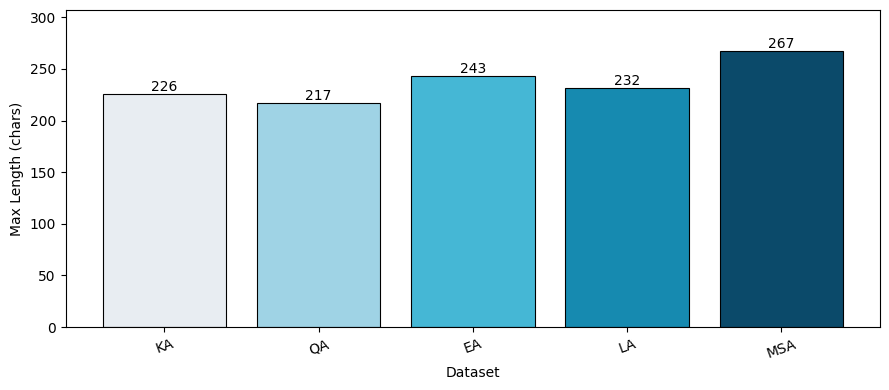

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(
    stats_df.index,
    stats_df["max"].values,
    color=colors[:len(stats_df)],
    edgecolor="black",
    linewidth=0.8
)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f"{h:.0f}", ha="center", va="bottom", fontsize=10)

#ax.set_title("Max Characters Length (Comparison)")
ax.set_xlabel("Dataset")
ax.set_ylabel("Max Length (chars)")
ax.set_ylim(0, stats_df["max"].max() * 1.15)
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()
plt.close(fig)


###Min Characters Length (Comparison)


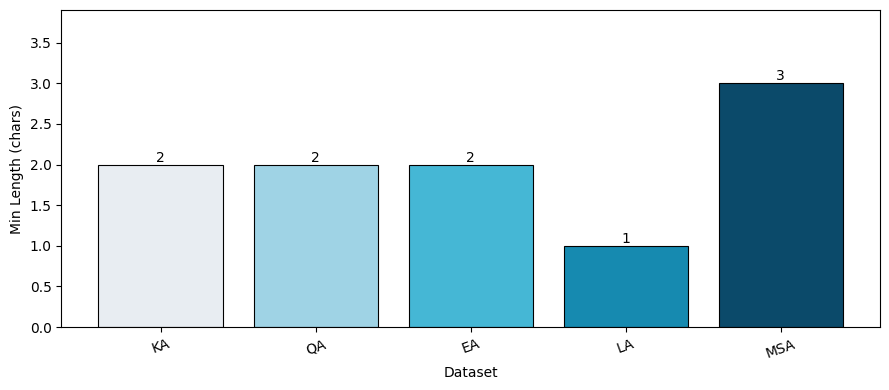

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(stats_df.index, stats_df["min"].values,color=colors[:len(stats_df)], edgecolor="black", linewidth=0.8)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f"{h:.0f}", ha="center", va="bottom", fontsize=10)

#ax.set_title("Min Characters Length (Comparison)")
ax.set_xlabel("Dataset")
ax.set_ylabel("Min Length (chars)")
ax.set_ylim(0, stats_df["min"].max() * 1.30)  # مساحة فوق عشان يبين الرقم
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()
plt.close(fig)

###Mean Characters Length (Comparison)


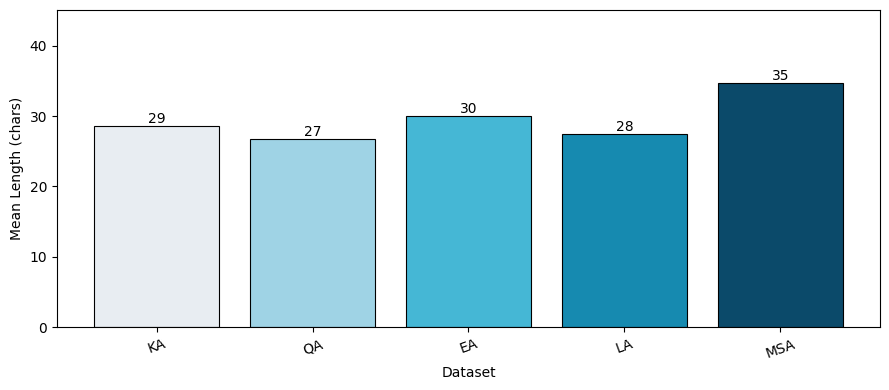

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(stats_df.index, stats_df["mean"].values,color=colors[:len(stats_df)], edgecolor="black", linewidth=0.8)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f"{h:.0f}", ha="center", va="bottom", fontsize=10)

#ax.set_title("Mean Characters Length (Comparison)")
ax.set_xlabel("Dataset")
ax.set_ylabel("Mean Length (chars)")
ax.set_ylim(0, stats_df["mean"].max() * 1.30)
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()
plt.close(fig)

###ALL in One, Characters

,min,mean,max
dataset,,,
KA,2.0,28.625032,226.0
QA,2.0,26.796557,217.0
EA,2.0,30.068506,243.0
LA,1.0,27.526166,232.0
MSA,3.0,34.691203,267.0


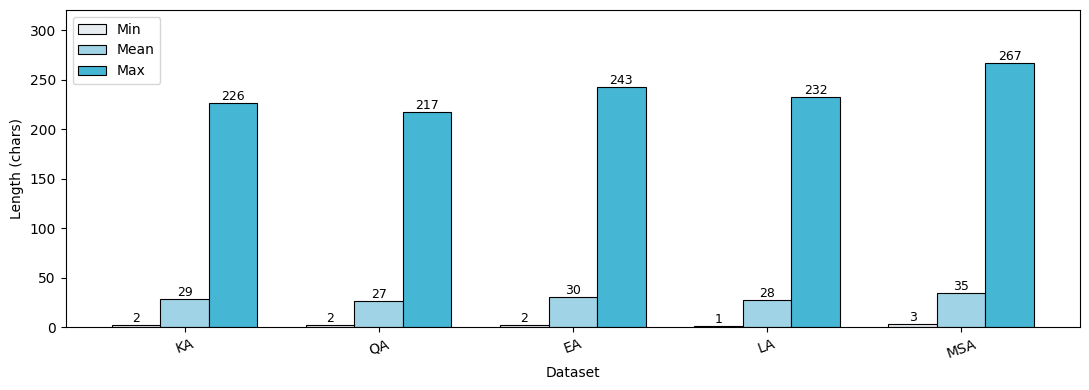

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for name, (df, col) in datasets.items():
    lens = df[col].fillna("").astype(str).str.len()
    rows.append({
        "dataset": name,
        "min": float(lens.min()),
        "mean": float(lens.mean()),
        "max": float(lens.max()),
    })

stats_df = pd.DataFrame(rows).set_index("dataset")
display(stats_df)

fig, ax = plt.subplots(figsize=(11, 4))

x = np.arange(len(stats_df.index))
w = 0.25

b_min  = ax.bar(x - w, stats_df["min"].values,  width=w, label="Min",  edgecolor="black", linewidth=0.8, color=colors[0])
b_mean = ax.bar(x,     stats_df["mean"].values, width=w, label="Mean", edgecolor="black", linewidth=0.8, color=colors[1])
b_max  = ax.bar(x + w, stats_df["max"].values,  width=w, label="Max",  edgecolor="black", linewidth=0.8, color=colors[2])

def add_labels(bars):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f"{h:.0f}", ha="center", va="bottom", fontsize=9)

add_labels(b_min)
add_labels(b_mean)
add_labels(b_max)

#ax.set_title("Characters Length (Min / Mean / Max) per Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Length (chars)")
ax.set_xticks(x)
ax.set_xticklabels(stats_df.index, rotation=20)
ax.set_ylim(0, stats_df[["min","mean","max"]].to_numpy().max() * 1.20)

ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)


##Plot Words in sentences

Avg word, max word length, min word length

In [ ]:
import pandas as pd

rows = []
for name, (df, col) in datasets.items():
    s = df[col].fillna("").astype(str).str.strip()
    word_counts = s.str.split().str.len()

    rows.append({
        "dataset": name,
        "min_words": word_counts.min(),
        "mean_words": word_counts.mean(),
        "max_words": word_counts.max(),
    })

stats_df1 = pd.DataFrame(rows).set_index("dataset")
display(stats_df)


,min,mean,max
dataset,,,
KA,2.0,28.625032,226.0
QA,2.0,26.796557,217.0
EA,2.0,30.068506,243.0
LA,1.0,27.526166,232.0
MSA,3.0,34.691203,267.0


###Min words Length (Comparison)

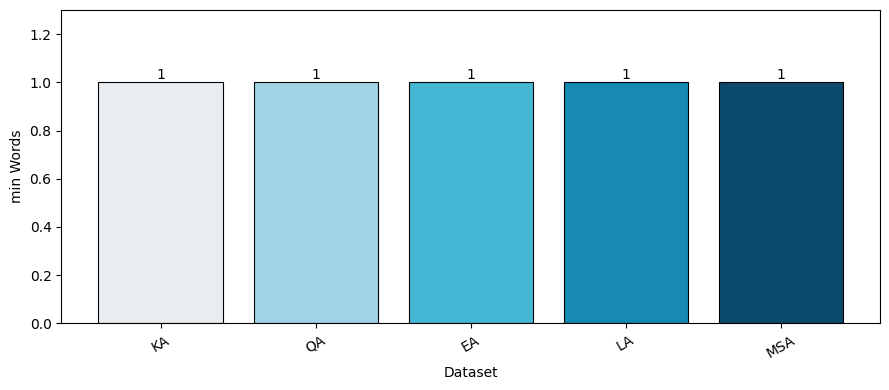

In [ ]:

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(stats_df1.index, stats_df1["min_words"].values,color=colors[:len(stats_df)], edgecolor="black", linewidth=0.8)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f"{h:.0f}", ha="center", va="bottom", fontsize=10)

#ax.set_title("Min Words Count (Comparison)")
ax.set_xlabel("Dataset")
ax.set_ylabel("min Words")
ax.set_ylim(0, 1.3)
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()
plt.close(fig)


###Max words Length (Comparison)

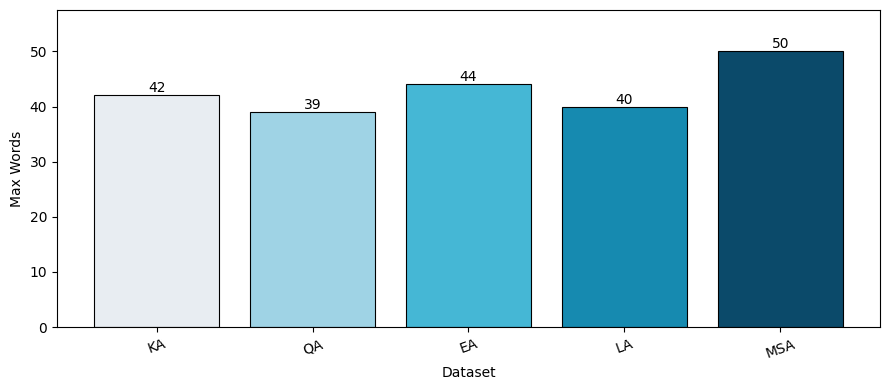

In [ ]:

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(stats_df1.index, stats_df1["max_words"].values,color=colors[:len(stats_df)], edgecolor="black", linewidth=0.8)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f"{h:.0f}", ha="center", va="bottom", fontsize=10)

#ax.set_title("Max Words Count (Comparison)")
ax.set_xlabel("Dataset")
ax.set_ylabel("Max Words")
ax.set_ylim(0, stats_df1["max_words"].max() * 1.15)
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()
plt.close(fig)


###Mean words Length (Comparison)

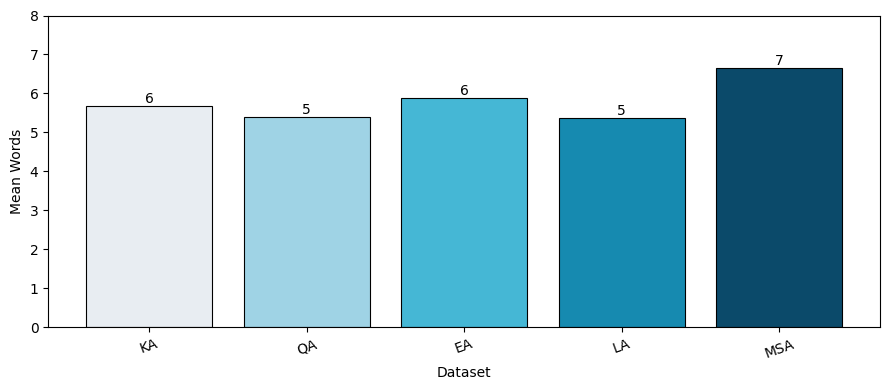

In [ ]:

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(stats_df1.index, stats_df1["mean_words"].values,color=colors[:len(stats_df)], edgecolor="black", linewidth=0.8)

for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f"{h:.0f}", ha="center", va="bottom", fontsize=10)

#ax.set_title("Mean Words Count (Comparison)")
ax.set_xlabel("Dataset")
ax.set_ylabel("Mean Words")
ax.set_ylim(0, 8)
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()
plt.close(fig)


###ALL in One, Characters

,min_words,mean_words,max_words
dataset,,,
KA,1,5.674077,42
QA,1,5.385520,39
EA,1,5.877779,44
LA,1,5.364588,40
MSA,1,6.647262,50


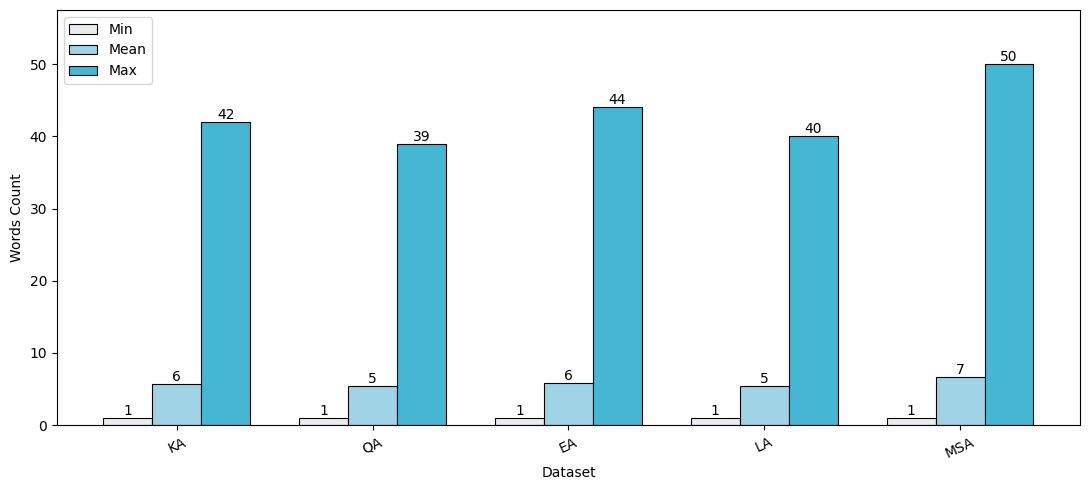

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rows = []
for name, (df, col) in datasets.items():
    s = df[col].fillna("").astype(str).str.strip()
    word_counts = s.str.split().str.len()
    rows.append({
        "dataset": name,
        "min_words": word_counts.min(),
        "mean_words": word_counts.mean(),
        "max_words": word_counts.max(),
    })

stats_df1 = pd.DataFrame(rows).set_index("dataset")
display(stats_df1)

labels = stats_df1.index.tolist()
x = np.arange(len(labels))
w = 0.25  # عرض كل بار

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - w, stats_df1["min_words"].values,
            width=w, label="Min", color=colors[0], edgecolor="black", linewidth=0.8)

b2 = ax.bar(x, stats_df1["mean_words"].values,
            width=w, label="Mean", color=colors[1], edgecolor="black", linewidth=0.8)

b3 = ax.bar(x + w, stats_df1["max_words"].values,
            width=w, label="Max", color=colors[2], edgecolor="black", linewidth=0.8)

def add_labels(bars):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h, f"{h:.0f}",
                ha="center", va="bottom", fontsize=10)

add_labels(b1)
add_labels(b2)
add_labels(b3)

#ax.set_title("Words Count (Min / Mean / Max) Comparison")
ax.set_xlabel("Dataset")
ax.set_ylabel("Words Count")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25)
ax.legend()

ax.set_ylim(0, stats_df1[["min_words", "mean_words", "max_words"]].to_numpy().max() * 1.15)

fig.tight_layout()
plt.show()
plt.close(fig)


#Unique Vocabulary

In [ ]:
import nltk
from nltk import word_tokenize
from nltk.util import ngrams
from collections import Counter

Stop words

In [ ]:
stopwords = pd.read_csv("/content/arabic_dialects_stopwords.csv")
len(stopwords)


1997

##KUWAIT word cloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import ImageFont
import random

colors = ["#E8EDF2", "#9FD3E5", "#45B7D5", "#168AB0", "#0B4A6A"]

def palette_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(colors)

font_path = "/content/arial.ttf"

In [ ]:
sentences = KuwaitDB['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized']
sentences = ' '.join(sentences)

tokens = sentences.split(" ")

COUNTS = Counter(tokens)

KWmost_common = COUNTS.most_common(500)

print(KWmost_common)

[('لو', 1512), ('سمحت', 1436), ('ابي', 1096), ('من', 1041), ('', 893), ('علا', 816), ('ما', 689), ('في', 683), ('ممكن', 657), ('اللي', 553), ('تقدر', 521), ('اقدر', 513), ('اي', 478), ('لي', 473), ('وين', 449), ('شنو', 436), ('حق', 421), ('انا', 412), ('هذا', 409), ('بس', 355), ('هني', 342), ('هذي', 312), ('راح', 276), ('الساعه', 261), ('لازم', 256), ('شي', 253), ('وايد', 248), ('واحد', 246), ('مو', 233), ('اخذ', 229), ('متا', 226), ('زين', 223), ('عشان', 218), ('لا', 217), ('رقم', 211), ('شلون', 210), ('الحين', 205), ('بعد', 197), ('عندك', 197), ('عندكم', 195), ('جم', 190), ('اذا', 178), ('ثانيه', 174), ('عندي', 172), ('مع', 169), ('هالشي', 163), ('شوي', 163), ('فيه', 161), ('تبي', 158), ('كل', 158), ('يوم', 154), ('هناك', 153), ('مشكور', 152), ('عن', 146), ('لك', 142), ('اسف', 140), ('و', 137), ('غرفه', 131), ('ان', 131), ('وحده', 130), ('ثلاثه', 129), ('انت', 128), ('وقت', 128), ('صفر', 128), ('ولا', 126), ('اروح', 125), ('عندنا', 124), ('اثنين', 123), ('خمسه', 122), ('شويه', 121), 

In [ ]:
KWmost_common_dict = {k: v for k, v in KWmost_common}
print(KWmost_common_dict)

{'لو': 1512, 'سمحت': 1436, 'ابي': 1096, 'من': 1041, '': 893, 'علا': 816, 'ما': 689, 'في': 683, 'ممكن': 657, 'اللي': 553, 'تقدر': 521, 'اقدر': 513, 'اي': 478, 'لي': 473, 'وين': 449, 'شنو': 436, 'حق': 421, 'انا': 412, 'هذا': 409, 'بس': 355, 'هني': 342, 'هذي': 312, 'راح': 276, 'الساعه': 261, 'لازم': 256, 'شي': 253, 'وايد': 248, 'واحد': 246, 'مو': 233, 'اخذ': 229, 'متا': 226, 'زين': 223, 'عشان': 218, 'لا': 217, 'رقم': 211, 'شلون': 210, 'الحين': 205, 'بعد': 197, 'عندك': 197, 'عندكم': 195, 'جم': 190, 'اذا': 178, 'ثانيه': 174, 'عندي': 172, 'مع': 169, 'هالشي': 163, 'شوي': 163, 'فيه': 161, 'تبي': 158, 'كل': 158, 'يوم': 154, 'هناك': 153, 'مشكور': 152, 'عن': 146, 'لك': 142, 'اسف': 140, 'و': 137, 'غرفه': 131, 'ان': 131, 'وحده': 130, 'ثلاثه': 129, 'انت': 128, 'وقت': 128, 'صفر': 128, 'ولا': 126, 'اروح': 125, 'عندنا': 124, 'اثنين': 123, 'خمسه': 122, 'شويه': 121, 'اني': 120, 'مره': 119, 'ثلاث': 118, 'اليوم': 116, 'دولار': 114, 'فيها': 110, 'جذي': 110, 'اشوف': 109, 'قبل': 104, 'كان': 102, 'يا': 102, 'ا

In [ ]:
all_stopwords_to_remove = stopwords['word'].tolist()

kuwait_items_unique = list(set(['','اليابان','لو','من','سمحت','من','في','ممكن','ما','اي','لي','شي','الساعه','لا','متا','رقم','علا','مو','هذا','واحد','مع','اذا','بعد'])) # Ensure unique items
all_stopwords_to_remove.extend(kuwait_items_unique)

for key in all_stopwords_to_remove:
    if key in KWmost_common_dict:
        del KWmost_common_dict[key]

print(KWmost_common_dict)

{'ابي': 1096, 'تقدر': 521, 'اقدر': 513, 'شنو': 436, 'حق': 421, 'هني': 342, 'لازم': 256, 'وايد': 248, 'زين': 223, 'شلون': 210, 'الحين': 205, 'عندكم': 195, 'جم': 190, 'ثانيه': 174, 'هالشي': 163, 'شوي': 163, 'تبي': 158, 'مشكور': 152, 'اسف': 140, 'غرفه': 131, 'وحده': 130, 'ثلاثه': 129, 'وقت': 128, 'اروح': 125, 'عندنا': 124, 'خمسه': 122, 'شويه': 121, 'مره': 119, 'جذي': 110, 'اشوف': 109, 'قريب': 101, 'الصبح': 101, 'حلو': 96, 'احجز': 95, 'رحله': 95, 'اكيد': 94, 'عطني': 90, 'تذكره': 88, 'مكان': 87, 'الباص': 86, 'حوالي': 84, 'باچر': 84, 'تاخذ': 83, 'نقدر': 80, 'سبعه': 80, 'تسعه': 79, 'سته': 77, 'واجد': 77, 'قاعد': 76, 'بجم': 72, 'القطار': 72, 'اربعه': 72, 'احصل': 71, 'اشتري': 70, 'الغرفه': 67, 'الليله': 67, 'حيل': 66, 'الرحله': 64, 'شكثر': 64, 'تقولي': 64, 'اوصل': 63, 'كنت': 63, 'اظن': 63, 'اكل': 62, 'ورني': 62, 'احسن': 60, 'محل': 60, 'ترا': 59, 'بعدين': 58, 'باص': 58, 'دقيقه': 58, 'طاوله': 57, 'اسوي': 57, 'الفندق': 56, 'سعر': 56, 'زياده': 56, 'تعطيني': 56, 'احس': 56, 'محطه': 55, 'ساعه': 55, 'ن

In [ ]:
len(all_stopwords_to_remove)

2019

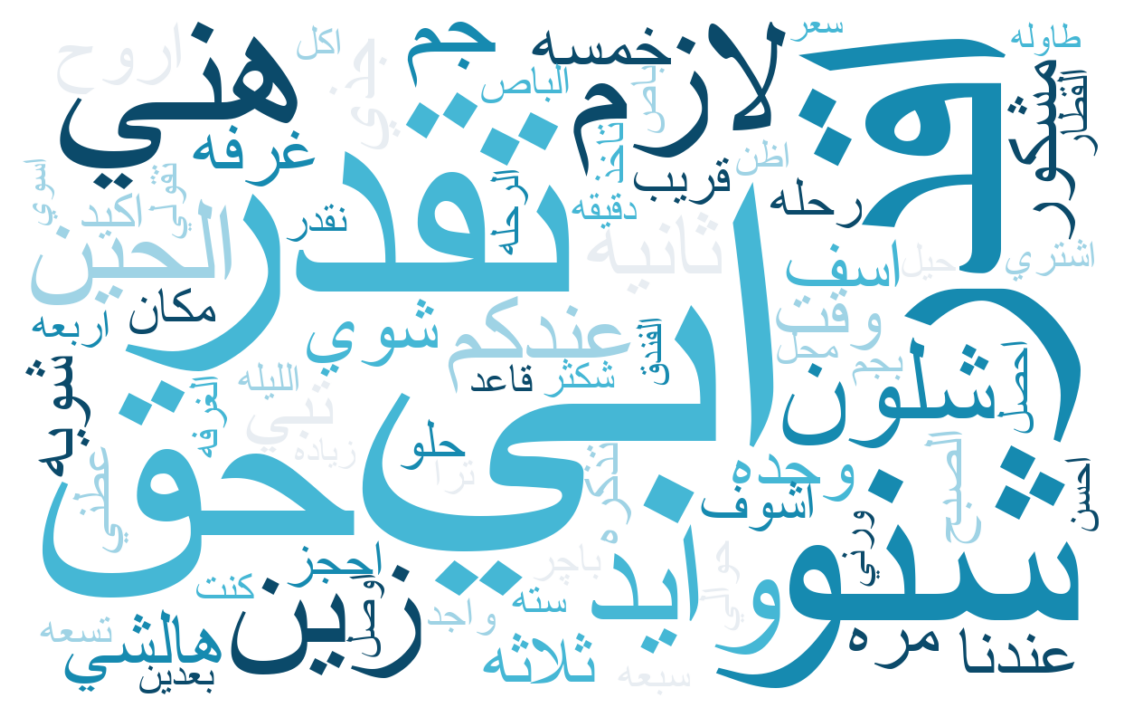

In [ ]:
 wc = WordCloud(
    background_color="white",
    font_path=font_path,
    width=400,
    height=250,
    scale=3,
    max_words=147,
    prefer_horizontal=0.95,
    collocations=False,
    min_font_size=12,
    max_font_size=160,
    relative_scaling=0.4,
    margin=2
).generate_from_frequencies(KWmost_common_dict)

wc = wc.recolor(color_func=palette_color_func, random_state=42)

plt.figure(figsize=(7, 7), dpi=200)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


##DOHA word cloud

In [ ]:
sentences = dohaDB['sent_DOH_punctuation_removed_and_tashkeel_and_normlaized']
sentences = ' '.join(sentences)

tokens = sentences.split(" ")

COUNTS = Counter(tokens)

DOHmost_common = COUNTS.most_common(500)

print(DOHmost_common)

[('في', 1756), ('لو', 1553), ('سمحت', 1529), ('ممكن', 1140), ('من', 851), ('هذي', 790), ('حق', 685), ('بغيت', 669), ('علا', 609), ('ما', 552), ('اي', 529), ('لي', 471), ('انا', 467), ('بس', 462), ('وين', 432), ('هني', 397), ('ابغي', 392), ('عندك', 376), ('اللي', 326), ('شنو', 325), ('كم', 325), ('واجد', 319), ('شي', 292), ('الساعه', 286), ('واحد', 258), ('يصير', 251), ('لازم', 248), ('ان', 216), ('دولار', 209), ('شلون', 207), ('مع', 203), ('لا', 203), ('تعطيني', 203), ('اذا', 202), ('اقدر', 202), ('مو', 190), ('الحين', 184), ('عندي', 176), ('تقدر', 171), ('او', 170), ('رقم', 165), ('اروح', 162), ('هو', 161), ('غرفه', 160), ('كل', 158), ('بعد', 155), ('زين', 152), ('اوكي', 149), ('متا', 145), ('هناك', 141), ('انت', 138), ('ثانيه', 136), ('مسامحه', 135), ('يوم', 135), ('ثلاثه', 130), ('عندنا', 130), ('اليابان', 128), ('عن', 127), ('اليوم', 123), ('بكره', 123), ('شوي', 122), ('تبغي', 121), ('اشوف', 120), ('خمسه', 114), ('شكرا', 113), ('مره', 107), ('قبل', 106), ('لك', 104), ('اخذ', 103), 

In [ ]:
DOHmost_common_dict = {k: v for k, v in DOHmost_common}
print(DOHmost_common_dict)

{'في': 1756, 'لو': 1553, 'سمحت': 1529, 'ممكن': 1140, 'من': 851, 'هذي': 790, 'حق': 685, 'بغيت': 669, 'علا': 609, 'ما': 552, 'اي': 529, 'لي': 471, 'انا': 467, 'بس': 462, 'وين': 432, 'هني': 397, 'ابغي': 392, 'عندك': 376, 'اللي': 326, 'شنو': 325, 'كم': 325, 'واجد': 319, 'شي': 292, 'الساعه': 286, 'واحد': 258, 'يصير': 251, 'لازم': 248, 'ان': 216, 'دولار': 209, 'شلون': 207, 'مع': 203, 'لا': 203, 'تعطيني': 203, 'اذا': 202, 'اقدر': 202, 'مو': 190, 'الحين': 184, 'عندي': 176, 'تقدر': 171, 'او': 170, 'رقم': 165, 'اروح': 162, 'هو': 161, 'غرفه': 160, 'كل': 158, 'بعد': 155, 'زين': 152, 'اوكي': 149, 'متا': 145, 'هناك': 141, 'انت': 138, 'ثانيه': 136, 'مسامحه': 135, 'يوم': 135, 'ثلاثه': 130, 'عندنا': 130, 'اليابان': 128, 'عن': 127, 'اليوم': 123, 'بكره': 123, 'شوي': 122, 'تبغي': 121, 'اشوف': 120, 'خمسه': 114, 'شكرا': 113, 'مره': 107, 'قبل': 106, 'لك': 104, 'اخذ': 103, 'كان': 103, 'اكيد': 100, 'اثنين': 100, 'قريب': 99, 'اسوي': 99, 'عطني': 99, 'رحله': 98, 'الصبح': 97, 'اوه': 97, 'شكثر': 96, 'ثلاث': 95, 'وق

In [ ]:
doha_items_unique = list(set(['اليابان','لو','من','سمحت','من','في','ممكن','ما','اي','لي','شي','الساعه','لا','متا','رقم','علا','مو','هذا','واحد','مع','اذا','بعد'])) # Ensure unique items
all_stopwords_to_remove.extend(doha_items_unique)

for key in all_stopwords_to_remove:
    if key in DOHmost_common_dict:
        del DOHmost_common_dict[key]

print(DOHmost_common_dict)

{'حق': 685, 'بغيت': 669, 'هني': 397, 'ابغي': 392, 'شنو': 325, 'واجد': 319, 'يصير': 251, 'لازم': 248, 'شلون': 207, 'تعطيني': 203, 'اقدر': 202, 'الحين': 184, 'تقدر': 171, 'اروح': 162, 'غرفه': 160, 'زين': 152, 'اوكي': 149, 'ثانيه': 136, 'مسامحه': 135, 'ثلاثه': 130, 'عندنا': 130, 'بكره': 123, 'شوي': 122, 'تبغي': 121, 'اشوف': 120, 'خمسه': 114, 'شكرا': 113, 'مره': 107, 'اكيد': 100, 'قريب': 99, 'اسوي': 99, 'عطني': 99, 'رحله': 98, 'الصبح': 97, 'شكثر': 96, 'وقت': 93, 'وحده': 87, 'تقريبا': 84, 'فندق': 81, 'سيد': 80, 'تسعه': 80, 'الباص': 79, 'احصل': 79, 'مكان': 79, 'حجز': 79, 'اخوي': 78, 'الليله': 78, 'كرسي': 77, 'ساعه': 77, 'تذكره': 75, 'عقب': 74, 'اظن': 74, 'احسن': 72, 'اتصل': 71, 'فيني': 71, 'زياده': 71, 'القطار': 70, 'ياباني': 69, 'تفضل': 68, 'محطه': 68, 'حلو': 68, 'اربعه': 65, 'احتاج': 65, 'ميه': 65, 'الفندق': 65, 'اشتري': 64, 'ياخذ': 64, 'شناطي': 63, 'احجز': 62, 'مشكور': 60, 'طاوله': 59, 'سته': 58, 'غلط': 58, 'معاك': 57, 'باخذ': 57, 'خذ': 55, 'باص': 55, 'كنت': 53, 'تاخذ': 53, 'محل': 53, 'تس

In [ ]:
len(all_stopwords_to_remove)

2040

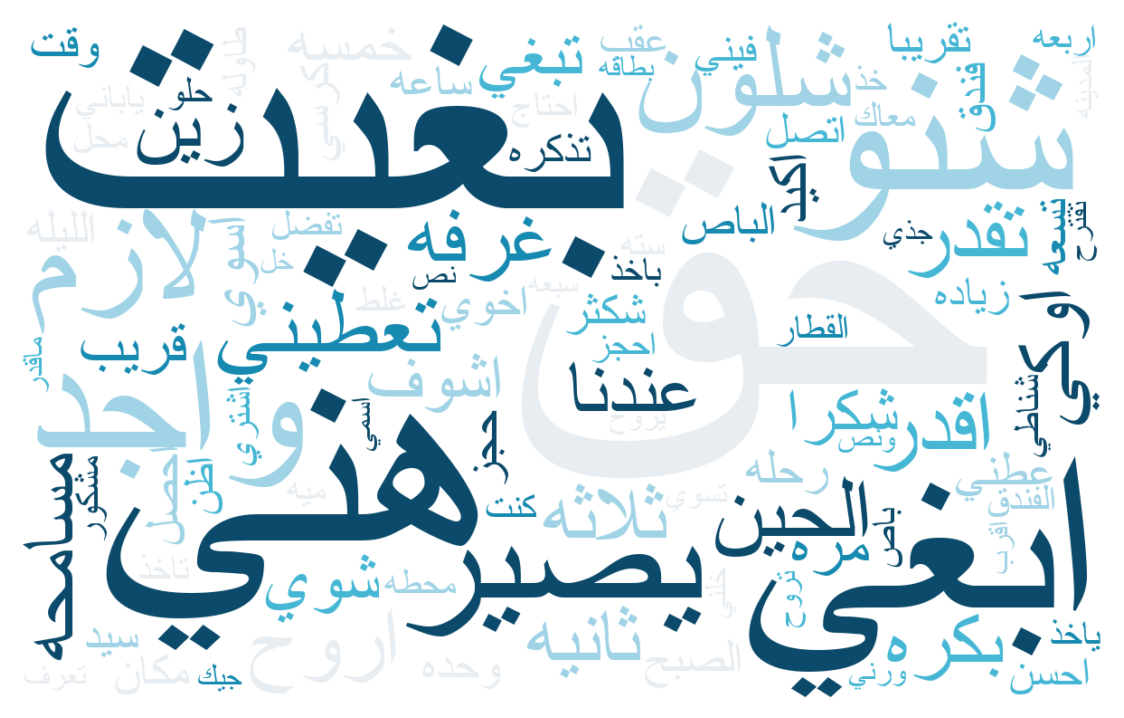

In [ ]:
wc = WordCloud(
    background_color="white",
    font_path=font_path,
    width=400,
    height=250,
    scale=3,
    max_words=149,
    prefer_horizontal=0.95,
    collocations=False,
    min_font_size=12,
    max_font_size=160,
    relative_scaling=0.4,
    margin=2
).generate_from_frequencies(DOHmost_common_dict)

wc = wc.recolor(color_func=palette_color_func, random_state=42)

plt.figure(figsize=(7, 7), dpi=200)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

##CAIRO word cloud

In [ ]:
sentences = cairoDB['sent_CAI_punctuation_removed_and_tashkeel_and_normlaized']
sentences = ' '.join(sentences)

tokens = sentences.split(" ")

COUNTS = Counter(tokens)

CAImost_common = COUNTS.most_common(500)

print(CAImost_common)

[('', 4942), ('من', 1610), ('ممكن', 1494), ('في', 1420), ('ده', 1255), ('انا', 1215), ('عايز', 942), ('لو', 859), ('و', 785), ('سمحت', 776), ('فضلك', 756), ('ايه', 670), ('مش', 556), ('علا', 503), ('اللي', 479), ('هنا', 421), ('فيه', 407), ('ديه', 391), ('فين', 371), ('هو', 369), ('انت', 350), ('بس', 329), ('عندك', 302), ('دي', 287), ('حاجه', 286), ('ما', 282), ('واحد', 253), ('كده', 244), ('اا', 235), ('دولار', 225), ('شويه', 213), ('اخد', 210), ('امتا', 203), ('كويس', 201), ('لا', 196), ('ايوه', 194), ('لازم', 170), ('تاني', 169), ('اني', 167), ('دلوقتي', 166), ('تلاته', 165), ('ان', 164), ('خمسه', 162), ('عشان', 160), ('يوم', 159), ('اي', 158), ('ازاي', 156), ('احنا', 155), ('عندي', 154), ('الساعه', 154), ('مع', 152), ('عاوز', 151), ('كام', 149), ('اقدر', 146), ('وقت', 146), ('اتنين', 146), ('كل', 146), ('اد', 145), ('جدا', 144), ('هناك', 143), ('اذا', 143), ('بعد', 135), ('اوضه', 134), ('رقم', 134), ('بكره', 132), ('علشان', 129), ('تسعه', 127), ('اسف', 117), ('تمام', 116), ('اليابا

In [ ]:
CAImost_common_dict = {k: v for k, v in CAImost_common}
print(CAImost_common_dict)

{'': 4942, 'من': 1610, 'ممكن': 1494, 'في': 1420, 'ده': 1255, 'انا': 1215, 'عايز': 942, 'لو': 859, 'و': 785, 'سمحت': 776, 'فضلك': 756, 'ايه': 670, 'مش': 556, 'علا': 503, 'اللي': 479, 'هنا': 421, 'فيه': 407, 'ديه': 391, 'فين': 371, 'هو': 369, 'انت': 350, 'بس': 329, 'عندك': 302, 'دي': 287, 'حاجه': 286, 'ما': 282, 'واحد': 253, 'كده': 244, 'اا': 235, 'دولار': 225, 'شويه': 213, 'اخد': 210, 'امتا': 203, 'كويس': 201, 'لا': 196, 'ايوه': 194, 'لازم': 170, 'تاني': 169, 'اني': 167, 'دلوقتي': 166, 'تلاته': 165, 'ان': 164, 'خمسه': 162, 'عشان': 160, 'يوم': 159, 'اي': 158, 'ازاي': 156, 'احنا': 155, 'عندي': 154, 'الساعه': 154, 'مع': 152, 'عاوز': 151, 'كام': 149, 'اقدر': 146, 'وقت': 146, 'اتنين': 146, 'كل': 146, 'اد': 145, 'جدا': 144, 'هناك': 143, 'اذا': 143, 'بعد': 135, 'اوضه': 134, 'رقم': 134, 'بكره': 132, 'علشان': 129, 'تسعه': 127, 'اسف': 117, 'تمام': 116, 'اليابان': 116, 'كان': 111, 'عن': 109, 'عندنا': 108, 'قوي': 108, 'كمان': 106, 'اشوف': 106, 'سبعه': 105, 'النهارده': 103, 'الصبح': 103, 'رحله': 102

In [ ]:
cairo_items_unique = list(set(['اا','','لو','من','سمحت','من','في','ممكن','ما','اي','لي','شي','الساعه','لا','متا','رقم','علا','مو','هذا','واحد','مع','اذا','بعد'])) # Ensure unique items
all_stopwords_to_remove.extend(cairo_items_unique)

for key in all_stopwords_to_remove:
    if key in CAImost_common_dict:
        del CAImost_common_dict[key]

print(CAImost_common_dict)

{'ده': 1255, 'عايز': 942, 'فضلك': 756, 'ديه': 391, 'فين': 371, 'دي': 287, 'حاجه': 286, 'شويه': 213, 'اخد': 210, 'امتا': 203, 'كويس': 201, 'لازم': 170, 'تاني': 169, 'دلوقتي': 166, 'تلاته': 165, 'خمسه': 162, 'ازاي': 156, 'عاوز': 151, 'كام': 149, 'اقدر': 146, 'وقت': 146, 'اتنين': 146, 'اد': 145, 'اوضه': 134, 'بكره': 132, 'علشان': 129, 'تسعه': 127, 'اسف': 117, 'تمام': 116, 'عندنا': 108, 'قوي': 108, 'كمان': 106, 'اشوف': 106, 'سبعه': 105, 'النهارده': 103, 'الصبح': 103, 'رحله': 102, 'اعمل': 101, 'تانيه': 99, 'اروح': 99, 'معاك': 99, 'سته': 98, 'اكتر': 98, 'لحد': 96, 'شكرا': 96, 'حوالي': 95, 'قريب': 95, 'اربعه': 93, 'تحب': 91, 'واحده': 91, 'مكان': 91, 'معايا': 88, 'مفروض': 85, 'القطر': 85, 'ميه': 85, 'لسه': 84, 'منين': 83, 'احجز': 82, 'كتير': 79, 'تلات': 75, 'تذكره': 75, 'بتاعي': 74, 'نص': 74, 'اشكرك': 74, 'رايح': 73, 'اكيد': 73, 'ياباني': 73, 'تمانيه': 73, 'عربيه': 70, 'تقدر': 70, 'عارف': 69, 'اشتري': 69, 'محتاج': 68, 'اديني': 68, 'حيكون': 67, 'كنت': 67, 'الاوضه': 67, 'عندكم': 67, 'عايزه': 66,

In [ ]:
len(all_stopwords_to_remove)

2062

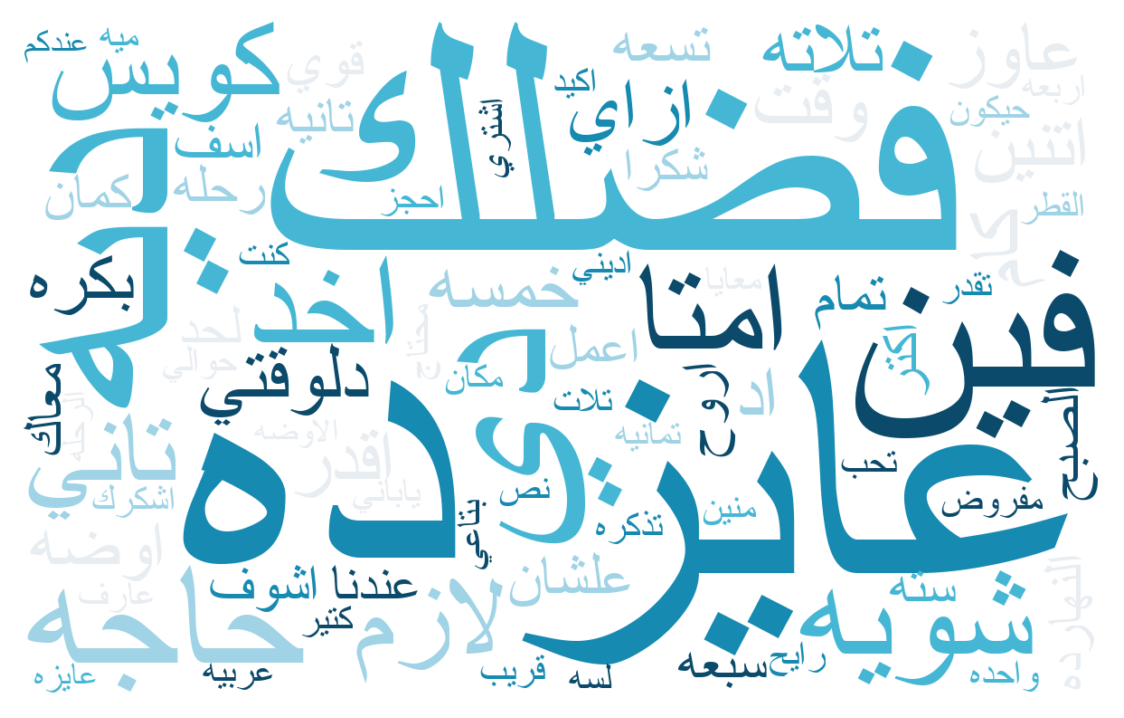

In [ ]:
wc = WordCloud(
    background_color="white",
    font_path=font_path,
    width=400,
    height=250,
    scale=3,
    max_words=149,
    prefer_horizontal=0.95,
    collocations=False,
    min_font_size=12,
    max_font_size=160,
    relative_scaling=0.4,
    margin=2
).generate_from_frequencies(CAImost_common_dict)

wc = wc.recolor(color_func=palette_color_func, random_state=42)

plt.figure(figsize=(7, 7), dpi=200)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

##BEIRUT word cloud

In [ ]:
sentences = beirutDB['sent_BEI_punctuation_removed_and_tashkeel_and_normlaized']
sentences = ' '.join(sentences)

tokens = sentences.split(" ")

COUNTS = Counter(tokens)

BEImost_common = COUNTS.most_common(500)

print(BEImost_common)

[('', 3851), ('بتريد', 1155), ('بدي', 1089), ('من', 905), ('ما', 826), ('فيك', 812), ('ازا', 707), ('اذا', 672), ('و', 646), ('في', 638), ('شي', 604), ('هيدا', 568), ('رح', 565), ('اي', 472), ('بس', 433), ('شو', 431), ('وين', 427), ('معروف', 413), ('فيي', 409), ('عمول', 406), ('كتير', 403), ('هون', 397), ('عندك', 347), ('اخد', 341), ('لازم', 324), ('بقدر', 322), ('انا', 297), ('بعد', 289), ('واحد', 259), ('دولار', 238), ('مع', 234), ('عن', 196), ('كيف', 188), ('مش', 187), ('ايه', 181), ('اللي', 179), ('انو', 177), ('هيدي', 175), ('منيح', 172), ('هوي', 168), ('تلاته', 163), ('او', 154), ('عندي', 153), ('ساعه', 152), ('كل', 151), ('بدك', 148), ('روح', 139), ('خمسه', 137), ('عنا', 133), ('عم', 130), ('اديش', 128), ('علا', 126), ('هلا', 125), ('كان', 121), ('اديه', 121), ('تاني', 119), ('لا', 118), ('بكرا', 117), ('شوف', 114), ('طيب', 111), ('شكرا', 110), ('الساعه', 108), ('اكيد', 107), ('معك', 106), ('معي', 105), ('تسعه', 104), ('هونيك', 101), ('شوي', 100), ('شويه', 98), ('فينا', 98), ('ي

In [ ]:
BEImost_common_dict = {k: v for k, v in BEImost_common}
print(BEImost_common_dict)

{'': 3851, 'بتريد': 1155, 'بدي': 1089, 'من': 905, 'ما': 826, 'فيك': 812, 'ازا': 707, 'اذا': 672, 'و': 646, 'في': 638, 'شي': 604, 'هيدا': 568, 'رح': 565, 'اي': 472, 'بس': 433, 'شو': 431, 'وين': 427, 'معروف': 413, 'فيي': 409, 'عمول': 406, 'كتير': 403, 'هون': 397, 'عندك': 347, 'اخد': 341, 'لازم': 324, 'بقدر': 322, 'انا': 297, 'بعد': 289, 'واحد': 259, 'دولار': 238, 'مع': 234, 'عن': 196, 'كيف': 188, 'مش': 187, 'ايه': 181, 'اللي': 179, 'انو': 177, 'هيدي': 175, 'منيح': 172, 'هوي': 168, 'تلاته': 163, 'او': 154, 'عندي': 153, 'ساعه': 152, 'كل': 151, 'بدك': 148, 'روح': 139, 'خمسه': 137, 'عنا': 133, 'عم': 130, 'اديش': 128, 'علا': 126, 'هلا': 125, 'كان': 121, 'اديه': 121, 'تاني': 119, 'لا': 118, 'بكرا': 117, 'شوف': 114, 'طيب': 111, 'شكرا': 110, 'الساعه': 108, 'اكيد': 107, 'معك': 106, 'معي': 105, 'تسعه': 104, 'هونيك': 101, 'شوي': 100, 'شويه': 98, 'فينا': 98, 'يا': 98, 'الصبح': 98, 'صفر': 92, 'محل': 91, 'اليوم': 91, 'تنين': 91, 'رقم': 87, 'وقت': 87, 'رام': 87, 'غير': 85, 'عطيني': 84, 'مره': 83, 'كم':

In [ ]:
beirut_items_unique = list(set(['لو','من','سمحت','من','في','ممكن','ما','اي','لي','شي','الساعه','لا','متا','رقم','علا','مو','هذا','واحد','مع','اذا','بعد','','عاليابان','اربعه','سبعه','سته','صفر','و']))
all_stopwords_to_remove.extend(beirut_items_unique)

for key in all_stopwords_to_remove:
    if key in BEImost_common_dict:
        del BEImost_common_dict[key]

print(BEImost_common_dict)

{'بتريد': 1155, 'بدي': 1089, 'فيك': 812, 'ازا': 707, 'هيدا': 568, 'رح': 565, 'شو': 431, 'معروف': 413, 'فيي': 409, 'عمول': 406, 'كتير': 403, 'هون': 397, 'اخد': 341, 'لازم': 324, 'بقدر': 322, 'انو': 177, 'هيدي': 175, 'منيح': 172, 'هوي': 168, 'تلاته': 163, 'ساعه': 152, 'بدك': 148, 'روح': 139, 'خمسه': 137, 'عنا': 133, 'عم': 130, 'اديش': 128, 'اديه': 121, 'تاني': 119, 'بكرا': 117, 'شوف': 114, 'شكرا': 110, 'اكيد': 107, 'معك': 106, 'معي': 105, 'تسعه': 104, 'هونيك': 101, 'شوي': 100, 'شويه': 98, 'فينا': 98, 'الصبح': 98, 'محل': 91, 'تنين': 91, 'وقت': 87, 'رام': 87, 'عطيني': 84, 'مره': 83, 'حلو': 82, 'استاذ': 82, 'اوضه': 82, 'وات': 82, 'هيك': 80, 'ايمتا': 79, 'اعمل': 77, 'اكتر': 75, 'وحده': 75, 'احجز': 71, 'ميه': 71, 'الباص': 70, 'ادي': 70, 'اذنك': 70, 'كنت': 68, 'نص': 68, 'كمان': 66, 'حدا': 65, 'بعتذر': 64, 'احسن': 64, 'ياباني': 62, 'باص': 60, 'تمانه': 60, 'هلق': 60, 'اشتري': 59, 'طاوله': 58, 'حد': 58, 'بعدين': 58, 'تبعك': 57, 'لهونيك': 57, 'خليني': 57, 'بدنا': 56, 'للاسف': 56, 'هيي': 55, 'اوك':

In [ ]:
len(all_stopwords_to_remove)

2089

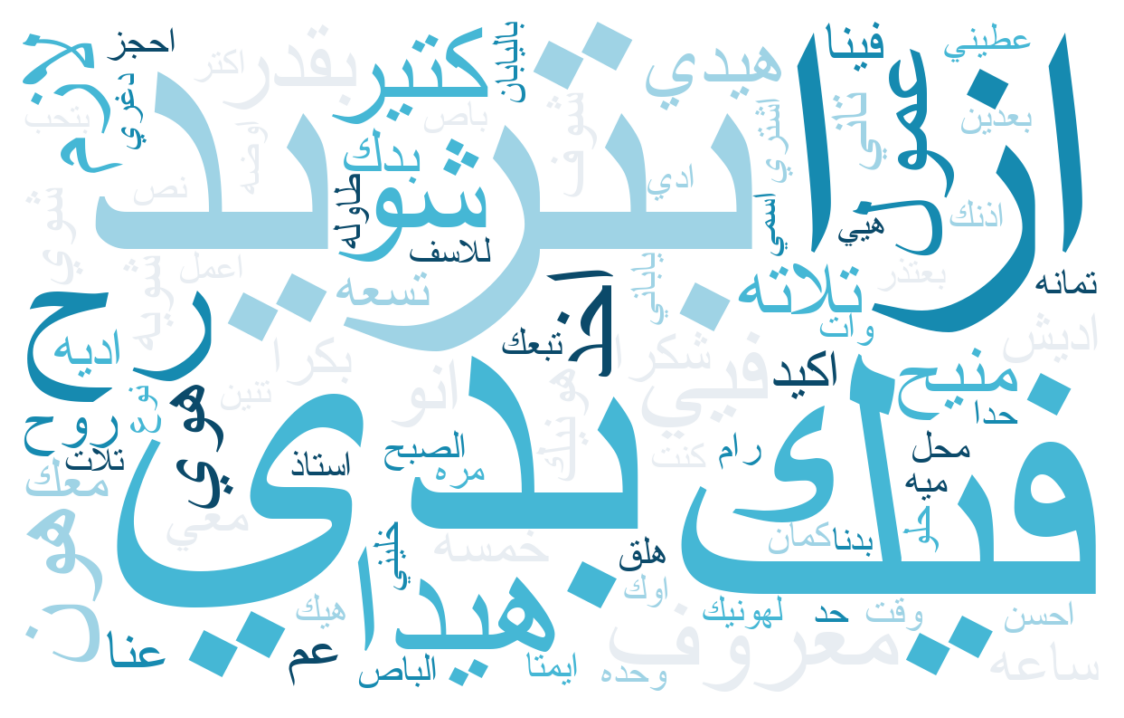

In [ ]:
wc = WordCloud(
    background_color="white",
    font_path=font_path,
    width=400,
    height=250,
    scale=3,
    max_words=142,
    prefer_horizontal=0.95,
    collocations=False,
    min_font_size=12,
    max_font_size=160,
    relative_scaling=0.4,
    margin=2
).generate_from_frequencies(BEImost_common_dict)

wc = wc.recolor(color_func=palette_color_func, random_state=42)

plt.figure(figsize=(7,7), dpi=200)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

##ARABIC MSA

In [ ]:
sentences = arabicMSA['sent_MSA_punctuation_removed_and_tashkeel_and_normlaized']
sentences = ' '.join(sentences)

tokens = sentences.split(" ")

COUNTS = Counter(tokens)

MSAmost_common = COUNTS.most_common(500)

print(MSAmost_common)

[('', 16424), ('من', 3057), ('هل', 2626), ('ان', 2171), ('في', 1754), ('فضلك', 1523), ('الا', 1113), ('هذا', 986), ('علا', 867), ('اريد', 739), ('لا', 612), ('هذه', 608), ('ما', 603), ('اين', 419), ('هنا', 404), ('لي', 397), ('اي', 394), ('يمكن', 338), ('انا', 336), ('هناك', 335), ('لقد', 330), ('لك', 319), ('هو', 313), ('يمكنني', 294), ('كم', 277), ('اود', 263), ('يمكنك', 260), ('عن', 245), ('انه', 236), ('بعض', 222), ('انها', 211), ('هي', 209), ('ذلك', 207), ('رقم', 197), ('حسنا', 194), ('نعم', 191), ('يوجد', 188), ('ثلاثه', 187), ('بعد', 186), ('لديك', 183), ('كيف', 176), ('خمسه', 173), ('شكرا', 165), ('واحد', 165), ('سوف', 164), ('متا', 163), ('جدا', 158), ('التي', 158), ('انني', 157), ('الان', 155), ('هلا', 153), ('اليابان', 147), ('استطيع', 146), ('الذي', 146), ('لم', 141), ('الساعه', 140), ('عشر', 139), ('صفر', 139), ('ماذا', 137), ('اذا', 135), ('غرفه', 134), ('شيء', 132), ('كل', 132), ('يجب', 131), ('ايه', 128), ('كان', 122), ('و', 122), ('مع', 120), ('اليوم', 119), ('ليس', 11

In [ ]:
MSAmost_common_dict = {k: v for k, v in MSAmost_common}
print(MSAmost_common_dict)

{'': 16424, 'من': 3057, 'هل': 2626, 'ان': 2171, 'في': 1754, 'فضلك': 1523, 'الا': 1113, 'هذا': 986, 'علا': 867, 'اريد': 739, 'لا': 612, 'هذه': 608, 'ما': 603, 'اين': 419, 'هنا': 404, 'لي': 397, 'اي': 394, 'يمكن': 338, 'انا': 336, 'هناك': 335, 'لقد': 330, 'لك': 319, 'هو': 313, 'يمكنني': 294, 'كم': 277, 'اود': 263, 'يمكنك': 260, 'عن': 245, 'انه': 236, 'بعض': 222, 'انها': 211, 'هي': 209, 'ذلك': 207, 'رقم': 197, 'حسنا': 194, 'نعم': 191, 'يوجد': 188, 'ثلاثه': 187, 'بعد': 186, 'لديك': 183, 'كيف': 176, 'خمسه': 173, 'شكرا': 165, 'واحد': 165, 'سوف': 164, 'متا': 163, 'جدا': 158, 'التي': 158, 'انني': 157, 'الان': 155, 'هلا': 153, 'اليابان': 147, 'استطيع': 146, 'الذي': 146, 'لم': 141, 'الساعه': 140, 'عشر': 139, 'صفر': 139, 'ماذا': 137, 'اذا': 135, 'غرفه': 134, 'شيء': 132, 'كل': 132, 'يجب': 131, 'ايه': 128, 'كان': 122, 'و': 122, 'مع': 120, 'اليوم': 119, 'ليس': 119, 'انت': 118, 'لديكم': 115, 'اخرا': 114, 'اسف': 110, 'الحصول': 110, 'لدينا': 109, 'دولارا': 108, 'اخر': 107, 'يا': 107, 'فقط': 103, 'حتا':

In [ ]:
arabic_items_unique = list(set(['لو','من','سمحت','من','في','ممكن','ما','اي','لي','شي','الساعه','لا','متا','رقم','علا','مو','هذا','واحد','مع','اذا','بعد','','عاليابان','اربعه','سبعه','سته','صفر','و']))
all_stopwords_to_remove.extend(arabic_items_unique)

for key in all_stopwords_to_remove:
    if key in MSAmost_common_dict:
        del MSAmost_common_dict[key]

print(MSAmost_common_dict)

{'فضلك': 1523, 'اريد': 739, 'لقد': 330, 'يمكنني': 294, 'اود': 263, 'يمكنك': 260, 'حسنا': 194, 'يوجد': 188, 'ثلاثه': 187, 'لديك': 183, 'خمسه': 173, 'شكرا': 165, 'انني': 157, 'استطيع': 146, 'غرفه': 134, 'يجب': 131, 'لديكم': 115, 'اخرا': 114, 'اسف': 110, 'الحصول': 110, 'لدينا': 109, 'دولارا': 108, 'اخر': 107, 'حتا': 103, 'اعتقد': 103, 'معذره': 102, 'واحده': 98, 'حوالي': 93, 'تسعه': 92, 'رحله': 89, 'اعطني': 88, 'توجد': 88, 'كنت': 87, 'الرحله': 83, 'الممكن': 83, 'وقت': 83, 'الفندق': 82, 'الغرفه': 82, 'القطار': 80, 'الطريق': 79, 'مكان': 79, 'الذهاب': 79, 'الليله': 78, 'تريد': 78, 'الحافله': 77, 'افضل': 75, 'تذكره': 75, 'سياره': 74, 'سيدي': 73, 'فندق': 73, 'بالقرب': 72, 'حجز': 70, 'مره': 69, 'اليس': 69, 'بالتاكيد': 68, 'اليابانيه': 67, 'دقيقه': 66, 'بطاقه': 65, 'ثمانيه': 65, 'اذهب': 63, 'لمده': 62, 'يبدو': 62, 'السيد': 61, 'جيد': 60, 'عشره': 60, 'نوع': 59, 'طوكيو': 59, 'المدينه': 59, 'معي': 58, 'ارني': 58, 'سيكون': 57, 'دعني': 57, 'المحطه': 57, 'محطه': 56, 'اشعر': 56, 'احصل': 56, 'ارغب': 55, 

In [ ]:
len(all_stopwords_to_remove)

2116

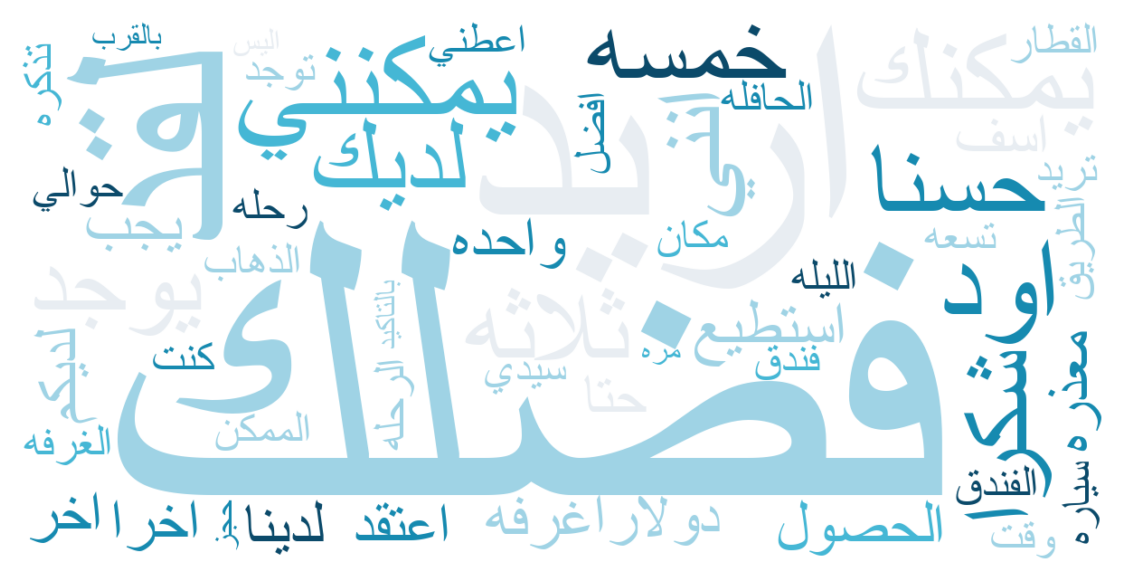

In [ ]:
wc = WordCloud(
    background_color="white",
    font_path=font_path,
    width=400,
    height=200,
    scale=3,
    max_words=149,
    prefer_horizontal=0.95,
    collocations=False,
    min_font_size=12,
    max_font_size=160,
    relative_scaling=0.4,
    margin=2
).generate_from_frequencies(MSAmost_common_dict)

wc = wc.recolor(color_func=palette_color_func, random_state=42)

plt.figure(figsize=(7, 7), dpi=200)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
!pip -q install arabic-reshaper python-bidi


#PLOT MPST FREQ WORD

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import font_manager
import arabic_reshaper
from bidi.algorithm import get_display


In [ ]:
len(KWmost_common_dict)

370

In [ ]:

def plot_top20_words(
    most_common_dict: dict,
    title_suffix: str,
    colors_palette: list,
    font_path: str,
    top_n: int = 20,
    figsize=(6, 4),
    dpi: int = 200,
):

    fix_ar = lambda s: get_display(arabic_reshaper.reshape(str(s)))

    top = sorted(most_common_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]

    words, freqs = zip(*top)

    words = [fix_ar(w) for w in words]

    cmap = LinearSegmentedColormap.from_list("p", colors_palette)

    bar_colors = cmap(np.linspace(0.15, 0.95, len(words)))

    fp = font_manager.FontProperties(fname=font_path)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    ax.barh(range(len(words)), freqs, color=bar_colors, edgecolor="black", linewidth=0.6)

    ax.set(
        yticks=range(len(words)),
        yticklabels=words,
        xlabel="Frequency",
    )

    ax.invert_yaxis()

    max_f = max(freqs)
    for i, v in enumerate(freqs):
        ax.text(v + max_f * 0.01, i, str(v), va="center", fontsize=9)

    for t in ax.get_yticklabels():
        t.set_fontproperties(fp)
    ax.set_xlim(0, max_f +120) # to increase X axis range

    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


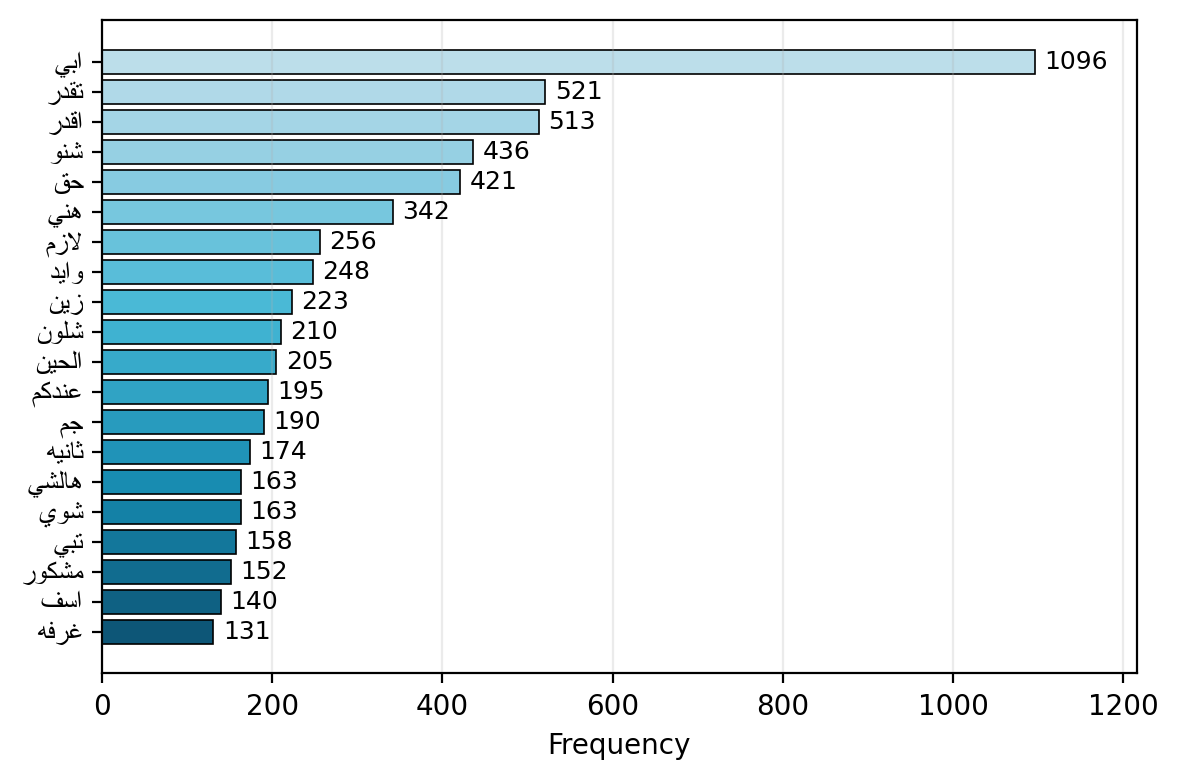

In [ ]:
colors_palette = ["#E8EDF2", "#9FD3E5", "#45B7D5", "#168AB0", "#0B4A6A"]

plot_top20_words(KWmost_common_dict,  "KW",    colors_palette, font_path)



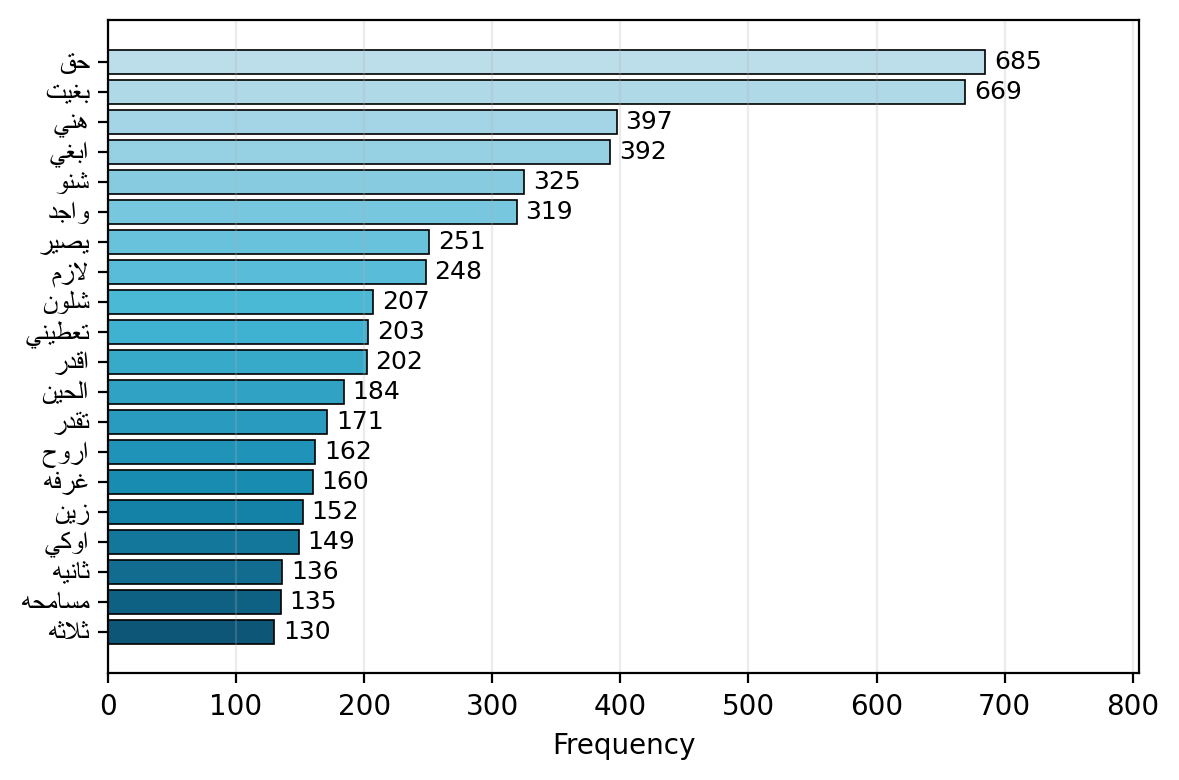

In [ ]:
plot_top20_words(DOHmost_common_dict, "Doha",  colors_palette, font_path)


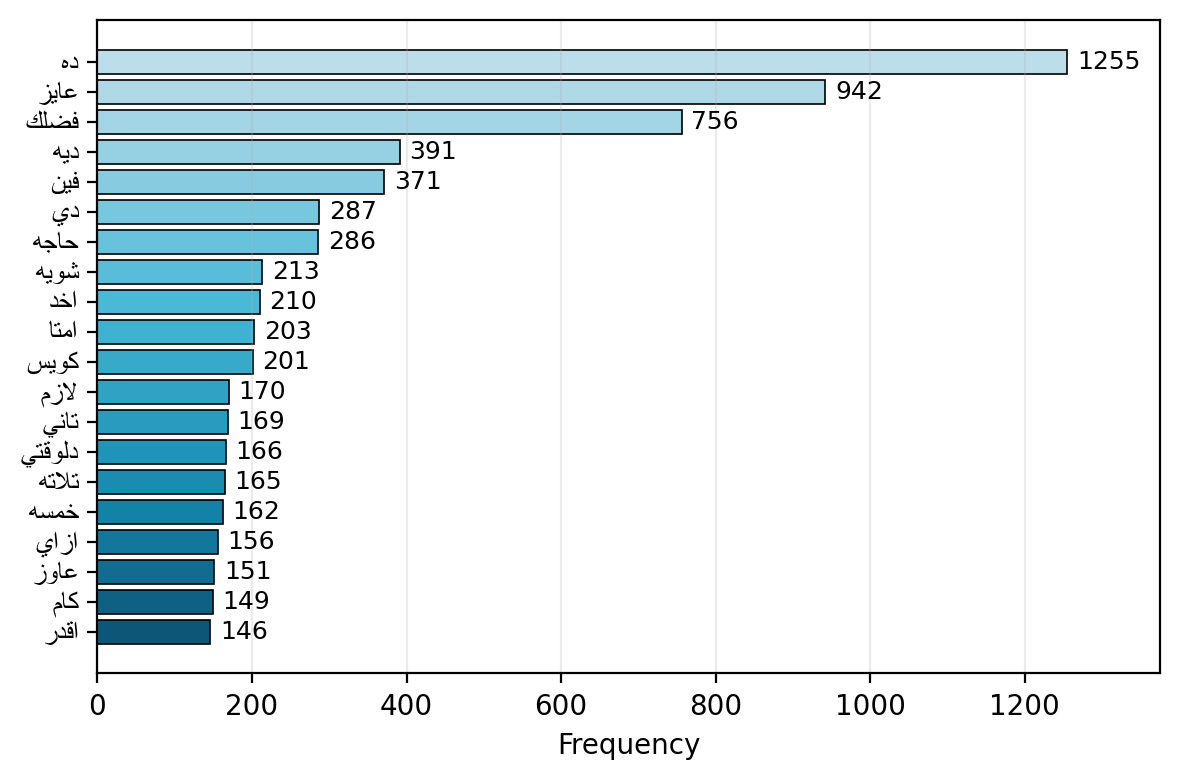

In [ ]:
plot_top20_words(CAImost_common_dict, "Cairo", colors_palette, font_path)


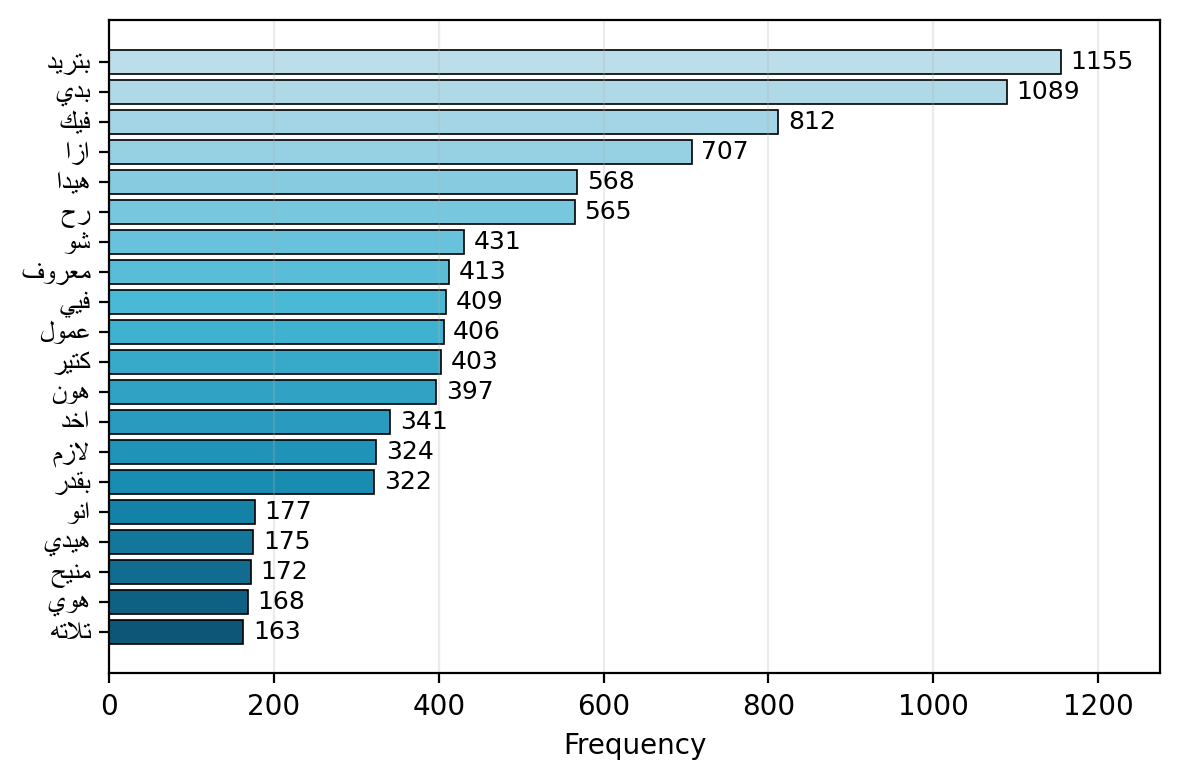

In [ ]:
plot_top20_words(BEImost_common_dict, "Beirut",colors_palette, font_path)


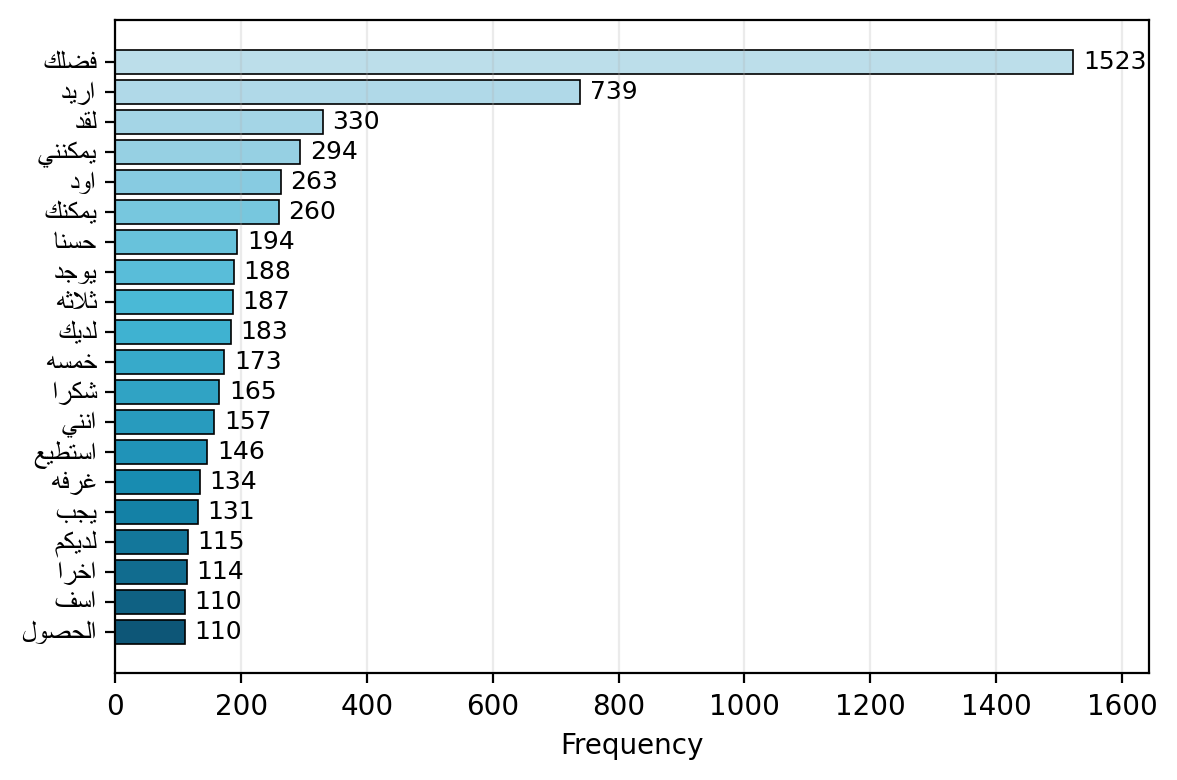

In [ ]:
plot_top20_words(MSAmost_common_dict, "MSA",   colors_palette, font_path)

#calculate statistics

Splitting the words (tokens), then taking only the unique ones.

In [ ]:
KuwaitDB['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized'].str.split()

,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized
0,"[تلقاها, في, اخر, القاعه, راح, اييب, لك, شويه,..."
1,"[تسوون, تعديلات]"
2,"[نبي, طاوله, يم, الدريشه]"
3,"[هناك, جدام, بيانات, السايح]"
4,"[ما, سمعت, بهالعنوان, من, قبل, قريب, من, هني]"
...,...
11556,"[ايه, انا, رايح, لوس, انجلوس]"
11557,"[بغرفه, الانتظار, بالمحطه]"
11558,"[خله, طويل]"
11559,"[اقدر, احجز, اي, مقعدين, لليله]"


In [ ]:
split_words_kuwait = KuwaitDB['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized'].str.split()
display(split_words_kuwait.head())

,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized
0,"[تلقاها, في, اخر, القاعه, راح, اييب, لك, شويه,..."
1,"[تسوون, تعديلات]"
2,"[نبي, طاوله, يم, الدريشه]"
3,"[هناك, جدام, بيانات, السايح]"
4,"[ما, سمعت, بهالعنوان, من, قبل, قريب, من, هني]"


In [ ]:
split_words_kuwait.head(3)


,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized
0,"[تلقاها, في, اخر, القاعه, راح, اييب, لك, شويه,..."
1,"[تسوون, تعديلات]"
2,"[نبي, طاوله, يم, الدريشه]"


In [ ]:
exploded_words_kuwait = split_words_kuwait.explode()
len(exploded_words_kuwait.unique())

11770

In [ ]:
print(len(exploded_words_kuwait.unique()))



11770


In [ ]:
exploded_words_kuwait[:10]

,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized
0,تلقاها
0,في
0,اخر
0,القاعه
0,راح
0,اييب
0,لك
0,شويه
0,منها
0,الحين


In [ ]:
split_words_doha = dohaDB['sent_DOH_punctuation_removed_and_tashkeel_and_normlaized'].str.split()
exploded_words_doha = split_words_doha.explode()
print(len(exploded_words_doha))
#cairo
split_words_cairo = cairoDB['sent_CAI_punctuation_removed_and_tashkeel_and_normlaized'].str.split()
exploded_words_cairo = split_words_cairo.explode()
print(len(exploded_words_cairo))
#beirut
split_words_beirut = beirutDB['sent_BEI_punctuation_removed_and_tashkeel_and_normlaized'].str.split()
exploded_words_beirut = split_words_beirut.explode()
print(len(exploded_words_beirut))
#msa
split_words_msa = arabicMSA['sent_MSA_punctuation_removed_and_tashkeel_and_normlaized'].str.split()
exploded_words_msa = split_words_msa.explode()
print(len(exploded_words_msa))




62262
67953
62020
76849


In [ ]:
print('number of rows:','QA',len(split_words_doha),'EA',len(split_words_cairo),'LA',len(split_words_beirut),'MSA',len(split_words_msa),'KA',len(split_words_kuwait))
print('number of total words:','QA',len(exploded_words_doha),'EA',len(exploded_words_cairo),'LA','MSA',len(exploded_words_beirut),len(exploded_words_msa),'KA',len(exploded_words_kuwait))
print('number of Unique words:','QA',len(exploded_words_doha.unique()),'EA','LA',len(exploded_words_cairo.unique()),'MSA',len(exploded_words_beirut.unique()),'KA',len(exploded_words_msa.unique()),len(exploded_words_kuwait.unique()))

#we will use it later for TTR
numberOfDohaWords=exploded_words_doha
numberOFCairoWords=exploded_words_cairo
numberOOfBeirutWords=exploded_words_beirut
numberOfkwaitiWords=exploded_words_kuwait
numberOOfMSAWords=exploded_words_msa

exploded_words_doha=exploded_words_doha.unique()
exploded_words_cairo=exploded_words_cairo.unique()
exploded_words_beirut=exploded_words_beirut.unique()
exploded_words_msa=exploded_words_msa.unique()
exploded_words_kuwait=exploded_words_kuwait.unique()

number of rows: QA 11561 EA 11561 LA 11561 MSA 11561 KA 11561
number of total words: QA 62262 EA 67953 LA MSA 62020 76849 KA 65598
number of Unique words: QA 9758 EA LA 11703 MSA 12464 KA 12819 11770


In [ ]:
x=1
y=2
print(x&y)

0


In [ ]:
import pandas as pd

V = {
    "MSA": set(exploded_words_msa),
    "QA": set(exploded_words_doha),
    "EA": set(exploded_words_cairo),
    "LA": set(exploded_words_beirut),
    "KA": set(exploded_words_kuwait),
}

msa = V["MSA"]

rows = []
for name, vocab in V.items():
    if name == "MSA":
      continue

    shared = vocab & msa
    rows.append({
        "Dialect": name,
        "Shared Unique Words with MSA": len(shared),
        "% of MSA Vocab in Dialect": round(100 * len(shared) / len(msa), 2) if len(msa) else 0.0,
        "% of Dialect Vocab in MSA": round(100 * len(shared) / len(vocab), 2) if len(vocab) else 0.0,
        "Unique Words in Dialect (Not in MSA)": len(vocab - msa),
    })

overlap_df = pd.DataFrame(rows).sort_values("Dialect").reset_index(drop=True)
display(overlap_df)

,Dialect,Shared Unique Words with MSA,% of MSA Vocab in Dialect,% of Dialect Vocab in MSA,Unique Words in Dialect (Not in MSA)
0,EA,4616,36.01,39.44,7087
1,KA,5811,45.33,49.37,5959
2,LA,3889,30.34,31.20,8575
3,QA,4338,33.84,44.46,5420


In [ ]:
list(sorted(shared))[:50]


['5',
 'ا',
 'اءتمان',
 'اا',
 'ابتداء',
 'ابتداءي',
 'ابحاث',
 'ابدا',
 'ابدل',
 'ابدلها',
 'ابرد',
 'ابريق',
 'ابريل',
 'ابطا',
 'ابعث',
 'ابلغ',
 'ابلغه',
 'ابلغها',
 'ابهامي',
 'ابواب',
 'ابوي',
 'ابي',
 'ابيض',
 'ابيع',
 'اتابعك',
 'اتاخر',
 'اتاكد',
 'اتبع',
 'اتبيع',
 'اتجاه',
 'اتجنب',
 'اتجنبه',
 'اتحسن',
 'اتحكم',
 'اتحمل',
 'اتذكر',
 'اترك',
 'اتساءل',
 'اتسلق',
 'اتسوجي',
 'اتسوق',
 'اتش',
 'اتصال',
 'اتصالك',
 'اتصالكم',
 'اتصل',
 'اتصلت',
 'اتصور',
 'اتعرف',
 'اتعلم']

###Latex Table converter

In [ ]:
# needs: \usepackage{booktabs} in  LaTeX preamble

latex_table = overlap_df.to_latex(
    index=False,
    escape=True,
    float_format="%.2f",
    column_format="lrrrr",
    caption="Lexical overlap between MSA and dialects.",
    label="tab:msa_dialect_overlap",
    bold_rows=False
)

print(latex_table)


\begin{table}
\caption{Lexical overlap between MSA and dialects.}
\label{tab:msa_dialect_overlap}
\begin{tabular}{lrrrr}
\toprule
Dialect & Shared Unique Words with MSA & \% of MSA Vocab in Dialect & \% of Dialect Vocab in MSA & Unique Words in Dialect (Not in MSA) \\
\midrule
EA & 4616 & 36.01 & 39.44 & 7087 \\
KA & 5811 & 45.33 & 49.37 & 5959 \\
LA & 3889 & 30.34 & 31.20 & 8575 \\
QA & 4338 & 33.84 & 44.46 & 5420 \\
\bottomrule
\end{tabular}
\end{table}



##Heatmap

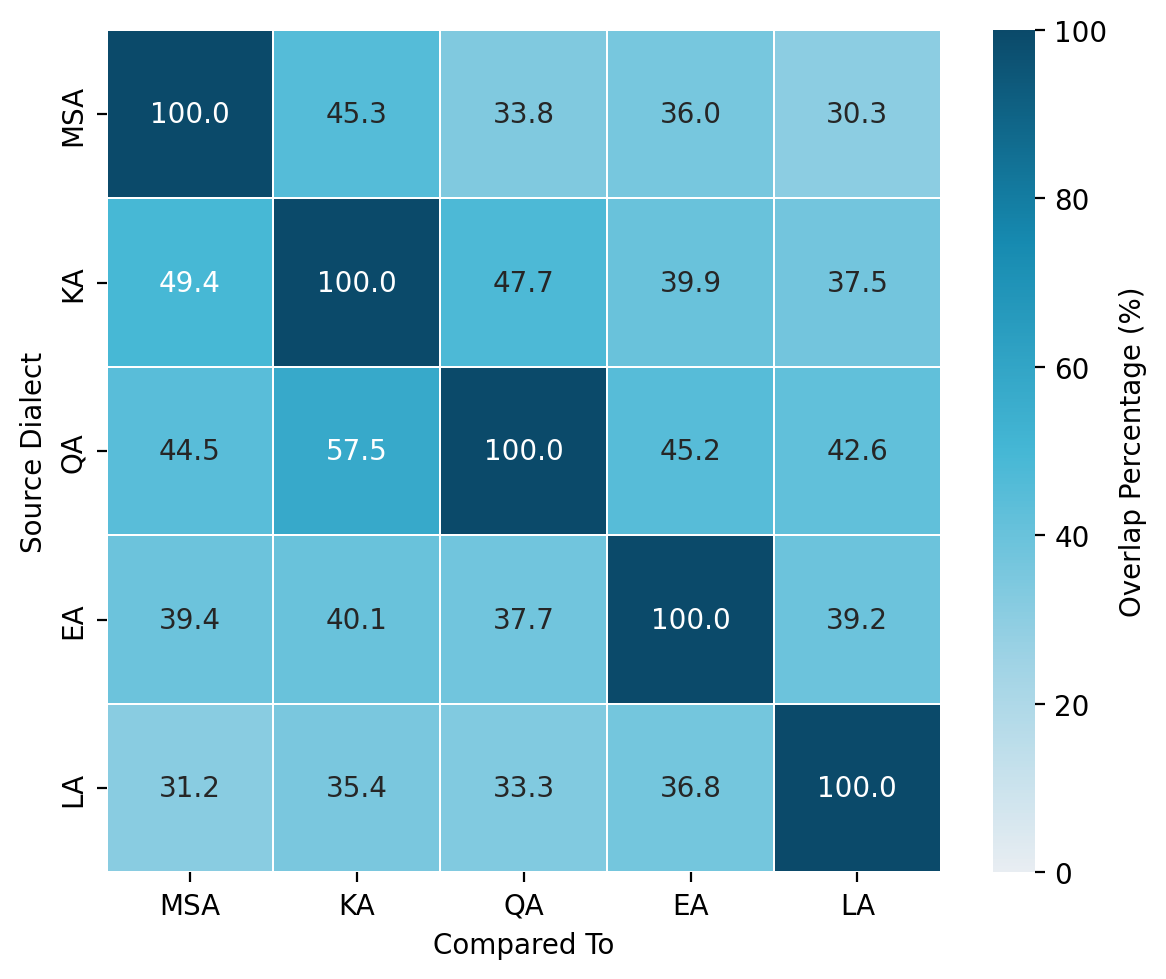

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

colors = ["#E8EDF2", "#9FD3E5", "#45B7D5", "#168AB0", "#0B4A6A"]
cmap = LinearSegmentedColormap.from_list("myPalette", colors)


V = {
    "MSA": set(exploded_words_msa),
    "KA":          set(exploded_words_kuwait),
    "QA":            set(exploded_words_doha),
    "EA":           set(exploded_words_cairo),
    "LA":          set(exploded_words_beirut),
}

order = [
    "MSA",
    "KA",
    "QA",
    "EA",
    "LA",
]

mat = pd.DataFrame(index=order, columns=order, dtype=float)
for r in order:
    for c in order:
        vr, vc = V[r], V[c]
        mat.loc[r, c] = 100 * len(vr & vc) / len(vr) if len(vr) else np.nan

plt.figure(figsize=(6, 5), dpi=200)
ax = sns.heatmap(
    mat,
    cmap=cmap, vmin=0, vmax=100,
    annot=True, fmt=".1f",
    linewidths=0.7, linecolor="white",
    cbar_kws={"label": "Overlap Percentage (%)"}
)

ax.set_xlabel("Compared To")
ax.set_ylabel("Source Dialect")
plt.tight_layout()
plt.savefig('compression_heatmap_poster_palette.jpg', format='jpeg', dpi=300, bbox_inches="tight")
plt.show()



الصف = لهجة المصدر (Source)

العمود = اللهجة اللي تقارن معها (Compared To)

الخلية (r, c) = “كم % من كلمات الصف موجودة في العمود”

In [ ]:
len(shared)

5811

In [ ]:
type(vocab & msa)

set

##Examples of selected sentences from the resulting corpus

In [ ]:
import pandas as pd

datasets = {
    "Kuwait": (KuwaitDB,  "sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized"),
    "Doha":   (dohaDB,    "sent_DOH_punctuation_removed_and_tashkeel_and_normlaized"),
    "Cairo":  (cairoDB,   "sent_CAI_punctuation_removed_and_tashkeel_and_normlaized"),
    "Beirut": (beirutDB,  "sent_BEI_punctuation_removed_and_tashkeel_and_normlaized"),
    "MSA":    (arabicMSA, "sent_MSA_punctuation_removed_and_tashkeel_and_normlaized"),
}

def side_by_side_head(datasets: dict, n: int = 30) -> pd.DataFrame:
    cols = {}
    for name, (df, col) in datasets.items():
        s = df[col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        cols[name] = s.head(n).reset_index(drop=True)
    return pd.DataFrame(cols)

compare_df = side_by_side_head(datasets, n=40)
display(compare_df)


,Kuwait,Doha,Cairo,Beirut,MSA
0,تلقاها في اخر القاعه راح اييب لك شويه منها الح...,موجود في نهايه الممر بجيب لك شوي الحين اذا احت...,هو في اخر القاعه انا حاجيبلك شويه دلوقتي لو مح...,هوي باخر الصاله رح جبلك شوي هلا اذا بدك شي تان...,انها في اخر القاعه سوف اتي لك ببعض منها الان ا...
1,تسوون تعديلات,تسوي تعديلات,بتعمل تبديلات,بتعمل تعديلات,هل تقومون بعمل تعديلات
2,نبي طاوله يم الدريشه,بغينا طاوله يم الدريشه,عايزين ترابيزه جنب الشباك,بدنا طاوله حد الشباك,نريد ماءده بجانب النافذه
3,هناك جدام بيانات السايح,هو ذاك الصوب بالضبط جدام استعلامات السياح بالضبط,ده قدامك هناك يادوبك قدام مكتب استعلامات السياحه,صار هونيك بالظبط قدام مكتب استعلامات السياح,هناك امام بيانات الساءح تماما
4,ما سمعت بهالعنوان من قبل قريب من هني,ما قط سمعت بهالعنوان في هالمنطقه من قبل,عمري ما سمعت عن العنوان ده هنا,بعمري ما سمعت بهالعنوان هون,لم اسمع بهذا العنوان من قبل بالقرب من هنا
5,كمل سيدا امشي بهالطريج لين تلقا صيدليه,امش سيده لين تشوف صيدليه,امشي علطول لحد ما تلقي صيدليه,روح دغري لحتا تشوف صيدليه,استمر في السير في هذا الطريق حتا تجد صيدليه
6,شنو اخر لون نازل هالموسم,شنو اللون اللي هابين فيه هالفتره,ايه اجدد لون في الموسم ده,شو هوي اجد لون لهالموسم,ما هو احدث لون هذا الموسم
7,بحالتي غالبا يكون للشغل ونادرا ما يكون للمتعه,في حالتي انا دايما حق شغل نادرا حق استانس,في الحاله بتاعتي بيبقا عاده شغل وقليل جدا ترفيه,بحالتي عاده بيكون شغل وقليل ليكون كرمال الترفيه,في حالتي غالبا ما يكون من اجل العمل ونادرا ما ...
8,بقعد يومين,بقعد يومين,هقعد يومين,رح ابقا يومين,ساقيم لمده يومين
9,ابي شعري يكون فيه تمويج قريب,بغيت كيرلي ضيق,انا عايز اعمل كيرلي جامد,بدي كيرلي ضيق,اريد تمويج متقارب بشعري


In [ ]:
# ✅ New cell: export compare_df (side-by-side sentences table) as LaTeX
# Note: for Arabic text, set escape=False so LaTeX doesn't break characters.

latex_tab = compare_df.to_latex(
    index=True,              # keep row index like your displayed table
    escape=False,            # important for Arabic text
    longtable=True,          # good if it spans multiple pages
    caption="Side-by-side examples from each dataset.",
    label="tab:side_by_side_examples"
)

print(latex_tab)


\begin{longtable}{llllll}
\caption{Side-by-side examples from each dataset.} \label{tab:side_by_side_examples} \\
\toprule
 & Kuwait & Doha & Cairo & Beirut & MSA \\
\midrule
\endfirsthead
\caption[]{Side-by-side examples from each dataset.} \\
\toprule
 & Kuwait & Doha & Cairo & Beirut & MSA \\
\midrule
\endhead
\midrule
\multicolumn{6}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
0 & تلقاها في اخر القاعه راح اييب لك شويه منها الحين اذا تبي اي شي ثاني بس علمني & موجود في نهايه الممر بجيب لك شوي الحين اذا احتجت شي ثاني خبرني & هو في اخر القاعه انا حاجيبلك شويه دلوقتي لو محتاج حاجه تانيه قولي & هوي باخر الصاله رح جبلك شوي هلا اذا بدك شي تاني بس عطيني خبر & انها في اخر القاعه سوف اتي لك ببعض منها الان اذا اردت اي شيءا اخر فقط اعلمني \\
1 & تسوون تعديلات & تسوي تعديلات & بتعمل تبديلات & بتعمل تعديلات & هل تقومون بعمل تعديلات \\
2 & نبي طاوله يم الدريشه & بغينا طاوله يم الدريشه & عايزين ترابيزه جنب الشباك & بدنا طاوله حد الشباك & نريد ماءده بجانب النافذه \\
3 & 

##Preliminary statistical metrics of the multidialectal corpus.

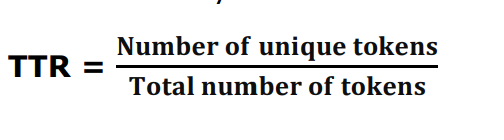

###TTR if we used a unique word without filtering it



In [ ]:

# number of the sentences (total)
print(
len(KuwaitDB['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized']),
len(dohaDB['sent_DOH_punctuation_removed_and_tashkeel_and_normlaized']),
len(beirutDB['sent_BEI_punctuation_removed_and_tashkeel_and_normlaized']),
len(cairoDB['sent_CAI_punctuation_removed_and_tashkeel_and_normlaized']),
len(arabicMSA['sent_MSA_punctuation_removed_and_tashkeel_and_normlaized']))

#number of words or (tokens)
print(f"""{len(numberOfkwaitiWords)},{len(numberOfDohaWords)},{len(numberOOfBeirutWords)},{len(numberOFCairoWords)},{len(numberOOfMSAWords)}""")

#number of unique words or (tokens), tokens in the dialect that do not exist in others.
print(len(exploded_words_doha),len(exploded_words_cairo),len(exploded_words_beirut),len(exploded_words_msa),len(exploded_words_kuwait))



11561 11561 11561 11561 11561
65598,62262,62020,67953,76849
9758 11703 12464 12819 11770


In [ ]:
#  unique-only الكلمات المقتصره على داتا وحده و موموجوده باي لهجه ثانيه

KW  = set(numberOfkwaitiWords)
DOH = set(numberOfDohaWords)
BEI = set(numberOOfBeirutWords)
CAI = set(numberOFCairoWords)
MSA = set(numberOOfMSAWords)

uniqueKuwaitWords_only = KW  - (DOH|BEI|CAI|MSA)
uniqueDohaWords_only = DOH- (KW  | BEI | CAI | MSA)
uniqueBeirutWords_only = BEI - (KW  | DOH | CAI | MSA)
uniqueCairoWords_only = CAI - (KW  | DOH | BEI | MSA)
uniqueMSAWords_only = MSA - (KW  | DOH | BEI | CAI)

print(len(uniqueKuwaitWords_only),
      len(uniqueDohaWords_only),
      len(uniqueBeirutWords_only),
      len(uniqueCairoWords_only),
      len(uniqueMSAWords_only))

#if ttr need it


3080 2471 5839 4513 5233


In [ ]:
print(stats_df1)
print(stats_df)

         min_words  mean_words  max_words
dataset                                  
Kuwait           1    5.674077         42
Doha             1    5.385520         39
Cairo            1    5.877779         44
Beirut           1    5.364588         40
MSA              1    6.647262         50
         min       mean    max
dataset                       
Kuwait   2.0  28.625032  226.0
Doha     2.0  26.796557  217.0
Cairo    2.0  30.068506  243.0
Beirut   1.0  27.526166  232.0
MSA      3.0  34.691203  267.0


In [ ]:
import pandas as pd

# 1) totals sent
total_sent = {
    "Kuwait": len(KuwaitDB['sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized']),
    "Doha":   len(dohaDB['sent_DOH_punctuation_removed_and_tashkeel_and_normlaized']),
    "Beirut": len(beirutDB['sent_BEI_punctuation_removed_and_tashkeel_and_normlaized']),
    "Cairo":  len(cairoDB['sent_CAI_punctuation_removed_and_tashkeel_and_normlaized']),
    "MSA":    len(arabicMSA['sent_MSA_punctuation_removed_and_tashkeel_and_normlaized']),
}

total_tokens = {
    "Kuwait": len(numberOfkwaitiWords),
    "Doha":   len(numberOfDohaWords),
    "Beirut": len(numberOOfBeirutWords),
    "Cairo":  len(numberOFCairoWords),
    "MSA":    len(numberOOfMSAWords),
}

unique_tokens = {
    "Kuwait": len(set(exploded_words_kuwait)),
    "Doha":   len(set(exploded_words_doha)),
    "Beirut": len(set(exploded_words_beirut)),
    "Cairo":  len(set(exploded_words_cairo)),
    "MSA":    len(set(exploded_words_msa)),
}

# 2) averages from stats_df1 and stats_df
avg_tokens = {k: float(stats_df1.loc[k, "mean_words"]) for k in ["Kuwait","Doha","Cairo","Beirut","MSA"]}
avg_chars  = {k: float(stats_df.loc[k,  "mean"])      for k in ["Kuwait","Doha","Cairo","Beirut","MSA"]}

# 3) TTR equation %%%
ttr = {k: (unique_tokens[k] / total_tokens[k] * 100) if total_tokens[k] else 0.0 for k in total_tokens}

# 4) table
order = ["MSA", "Kuwait", "Doha", "Cairo", "Beirut"]

table2 = pd.DataFrame(index=[
    "Total Sentences",
    "Total Tokens",
    "Unique Tokens",
    "Type–Token Ratio (TTR) %",
    "Avg. Sentence Length (Tokens)",
    "Avg. Sentence Length (Chars)",
])

for name in order:
    table2[name] = [
        total_sent[name],
        total_tokens[name],
        unique_tokens[name],
        round(ttr[name], 2),
        round(avg_tokens[name], 2),
        round(avg_chars[name], 2),
    ]

display(table2)



,MSA,Kuwait,Doha,Cairo,Beirut
Total Sentences,11561.00,11561.00,11561.00,11561.00,11561.00
Total Tokens,76849.00,65598.00,62262.00,67953.00,62020.00
Unique Tokens,12819.00,11770.00,9758.00,11703.00,12464.00
Type–Token Ratio (TTR) %,16.68,17.94,15.67,17.22,20.10
Avg. Sentence Length (Tokens),6.65,5.67,5.39,5.88,5.36
Avg. Sentence Length (Chars),34.69,28.63,26.80,30.07,27.53


In [ ]:

# 1) make a formatted copy (commas for large ints)
table2_ltx = table2.copy()
for r in ["Total Sentences", "Total Tokens", "Unique Tokens"]:
    table2_ltx.loc[r] = table2_ltx.loc[r].map(lambda x: f"{int(float(x)):,}")

# 2) export to LaTeX
latex_table2 = table2_ltx.to_latex(
    escape=False,
    index=True,
    header=True,
    caption="Preliminary statistical metrics of the multidialectal corpus.",
    label="tab:table2_metrics"
)

print(latex_table2)


\begin{table}
\caption{Preliminary statistical metrics of the multidialectal corpus.}
\label{tab:table2_metrics}
\begin{tabular}{llllll}
\toprule
 & MSA & Kuwait & Doha & Cairo & Beirut \\
\midrule
Total Sentences & 11,561 & 11,561 & 11,561 & 11,561 & 11,561 \\
Total Tokens & 76,849 & 65,598 & 62,262 & 67,953 & 62,020 \\
Unique Tokens & 12,819 & 11,770 & 9,758 & 11,703 & 12,464 \\
Type–Token Ratio (TTR) % & 16.680000 & 17.940000 & 15.670000 & 17.220000 & 20.100000 \\
Avg. Sentence Length (Tokens) & 6.650000 & 5.670000 & 5.390000 & 5.880000 & 5.360000 \\
Avg. Sentence Length (Chars) & 34.690000 & 28.630000 & 26.800000 & 30.070000 & 27.530000 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipython-input-3050994279.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_ltx.loc[r] = table2_ltx.loc[r].map(lambda x: f"{int(float(x)):,}")
/tmp/ipython-input-3050994279.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_ltx.loc[r] = table2_ltx.loc[r].map(lambda x: f"{int(float(x)):,}")
/tmp/ipython-input-3050994279.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_ltx.loc[r] = table2_ltx.loc[r].map(lambda x: f"{int(f

###TTR if we used a unique word that exists only in one dialect.


In [ ]:
unique_tokens = {
    "Kuwait": len(set(uniqueKuwaitWords_only)),
    "Doha":   len(set(uniqueDohaWords_only)),
    "Beirut": len(set(uniqueBeirutWords_only)),
    "Cairo":  len(set(uniqueCairoWords_only)),
    "MSA":    len(set(uniqueMSAWords_only)),
}
ttr = {k: (unique_tokens[k] / total_tokens[k] * 100) if total_tokens[k] else 0.0 for k in total_tokens}

for name in order:
    table2[name] = [
        total_sent[name],
        total_tokens[name],
        unique_tokens[name],
        round(ttr[name], 2),
        round(avg_tokens[name], 2),
        round(avg_chars[name], 2),
    ]

display(table2)

,MSA,Kuwait,Doha,Cairo,Beirut
Total Sentences,11561.00,11561.00,11561.00,11561.00,11561.00
Total Tokens,76849.00,65598.00,62262.00,67953.00,62020.00
Unique Tokens,5233.00,3080.00,2471.00,4513.00,5839.00
Type–Token Ratio (TTR) %,6.81,4.70,3.97,6.64,9.41
Avg. Sentence Length (Tokens),6.65,5.67,5.39,5.88,5.36
Avg. Sentence Length (Chars),34.69,28.63,26.80,30.07,27.53


In [ ]:
table2_fmt = table2.copy()
for r in ["Total Sentences", "Total Tokens", "Unique Tokens"]:
    table2_fmt.loc[r] = table2_fmt.loc[r].map(lambda x: f"{int(x):,}")
display(table2_fmt)

/tmp/ipython-input-754880838.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_fmt.loc[r] = table2_fmt.loc[r].map(lambda x: f"{int(x):,}")
/tmp/ipython-input-754880838.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_fmt.loc[r] = table2_fmt.loc[r].map(lambda x: f"{int(x):,}")
/tmp/ipython-input-754880838.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_fmt.loc[r] = table2_fmt.loc[r].map(lambda x: f"{int(x):,}")
/tmp/ipyth

,MSA,Kuwait,Doha,Cairo,Beirut
Total Sentences,"11,561","11,561","11,561","11,561","11,561"
Total Tokens,"76,849","65,598","62,262","67,953","62,020"
Unique Tokens,"5,233","3,080","2,471","4,513","5,839"
Type–Token Ratio (TTR) %,6.81,4.7,3.97,6.64,9.41
Avg. Sentence Length (Tokens),6.65,5.67,5.39,5.88,5.36
Avg. Sentence Length (Chars),34.69,28.63,26.8,30.07,27.53


In [ ]:

# 1) make a formatted copy (commas for large ints)
table2_ltx = table2.copy()
for r in ["Total Sentences", "Total Tokens", "Unique Tokens"]:
    table2_ltx.loc[r] = table2_ltx.loc[r].map(lambda x: f"{int(float(x)):,}")

# 2) export to LaTeX
latex_table2 = table2_ltx.to_latex(
    escape=False,
    index=True,
    header=True,
    caption="Preliminary statistical metrics of the multidialectal corpus.",
    label="tab:table2_metrics"
)

print(latex_table2)


\begin{table}
\caption{Preliminary statistical metrics of the multidialectal corpus.}
\label{tab:table2_metrics}
\begin{tabular}{llllll}
\toprule
 & MSA & Kuwait & Doha & Cairo & Beirut \\
\midrule
Total Sentences & 11,561 & 11,561 & 11,561 & 11,561 & 11,561 \\
Total Tokens & 76,849 & 65,598 & 62,262 & 67,953 & 62,020 \\
Unique Tokens & 5,233 & 3,080 & 2,471 & 4,513 & 5,839 \\
Type–Token Ratio (TTR) % & 6.810000 & 4.700000 & 3.970000 & 6.640000 & 9.410000 \\
Avg. Sentence Length (Tokens) & 6.650000 & 5.670000 & 5.390000 & 5.880000 & 5.360000 \\
Avg. Sentence Length (Chars) & 34.690000 & 28.630000 & 26.800000 & 30.070000 & 27.530000 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipython-input-3050994279.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_ltx.loc[r] = table2_ltx.loc[r].map(lambda x: f"{int(float(x)):,}")
/tmp/ipython-input-3050994279.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_ltx.loc[r] = table2_ltx.loc[r].map(lambda x: f"{int(float(x)):,}")
/tmp/ipython-input-3050994279.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11,561' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2_ltx.loc[r] = table2_ltx.loc[r].map(lambda x: f"{int(f

In [ ]:
KuwaitDB.head(1)


,Unnamed: 0,sentID.BTEC,split,lang,sent,sent_kuwaiti_GPT_Translated,sent_kuwaiti,Type (B/H),Translator Initials,sent_kuwaiti_punctuation_removed,sent_punctuation_removed,sent_kuwaiti_punctuation_removed_and_tashkeel,sent_punctuation_removed_and_tashkeel,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized,sent_punctuation_removed_and_tashkeel_and_normlaized
0,0,0,corpus-6-train,MSA,إنها في أخر القاعة . سوف آتي لك ببعض منها الآن...,هي بنهاية القاعة. بجيب لك شوية منها الحين. إذا...,تلقاها في آخر القاعة. راح اييب لك شوية منها ال...,H,H,تلقاها في آخر القاعة راح اييب لك شوية منها الح...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,تلقاها في آخر القاعة راح اييب لك شوية منها الح...,إنها في أخر القاعة سوف آتي لك ببعض منها الآن ...,تلقاها في اخر القاعه راح اييب لك شويه منها الح...,انها في اخر القاعه سوف اتي لك ببعض منها الان ...


In [ ]:
KuwaitDB.tail(1)

,Unnamed: 0,sentID.BTEC,split,lang,sent,sent_kuwaiti_GPT_Translated,sent_kuwaiti,Type (B/H),Translator Initials,sent_kuwaiti_punctuation_removed,sent_punctuation_removed,sent_kuwaiti_punctuation_removed_and_tashkeel,sent_punctuation_removed_and_tashkeel,sent_kuwaiti_punctuation_removed_and_tashkeel_and_normlaized,sent_punctuation_removed_and_tashkeel_and_normlaized
11560,11999,19970,corpus-6-train,MSA,هل لديك مائدة لأربعة أشخاص ؟,عندكم طاولة لأربعة أشخاص؟,عندكم طاولة لأربعة أشخاص؟,H,H,عندكم طاولة لأربعة أشخاص,هل لديك مائدة لأربعة أشخاص,عندكم طاولة لأربعة أشخاص,هل لديك مائدة لأربعة أشخاص,عندكم طاوله لاربعه اشخاص,هل لديك ماءده لاربعه اشخاص
